### Enable importing modules from the parent project directory


In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))  # Adds project root

### Importing necessary libraries

In [2]:
import pandas as pd  # Data manipulation and DataFrame support
import numpy as np  # Numerical computing with arrays
import math  # Basic mathematical functions
import matplotlib.pyplot as plt  # Plotting and visualization
from sklearn.metrics import mean_squared_error, mean_absolute_error  # Evaluation metrics
from statistics import mode  # Compute statistical mode
import folium  # Interactive maps (leaflet.js-based)
from folium.plugins import MarkerCluster  # Cluster markers on maps
from scipy.stats import pearsonr  # Pearson correlation calculation
from sklearn.preprocessing import StandardScaler  # Z-score normalization
from sklearn.preprocessing import MinMaxScaler  # Scale features to 0–1 range
from tqdm import tqdm  # Progress bars for loops
from prophet import Prophet  # Facebook Prophet time series forecasting
import random  # Random number generation
from sklearn.impute import SimpleImputer  # Basic missing value imputation
from typing import Dict  # Type hinting for dictionaries
import seaborn as sns  # Statistical data visualization
from sklearn.impute import SimpleImputer  # (Duplicate) Basic imputation again
from IPython.display import display, HTML  # Pretty HTML display in notebooks
from sklearn.decomposition import PCA  # Principal Component Analysis (dimensionality reduction)
from sklearn.preprocessing import StandardScaler  # (Duplicate) Z-score scaling
from statsmodels.tsa.holtwinters import ExponentialSmoothing  # Time series smoothing & forecasting
from sklearn.ensemble import RandomForestRegressor  # Random Forest for regression tasks
from sklearn.inspection import permutation_importance  # Feature importance via permutation
import warnings  # Control warning messages
warnings.filterwarnings("ignore")  # Suppress warnings (useful in notebooks)
from prophet.plot import plot_plotly, plot_components_plotly  # Plotting Prophet results
from prophet.diagnostics import cross_validation, performance_metrics  # Prophet diagnostics tools

In [3]:
from typing import List, Tuple  # Type hinting for lists and tuples

from Algorithms.CDREC import CDRec  # Collaborative Denoising for matrix completion
from Algorithms.TKCM import TKCM  # Top-k Case Matching (basic version)
from Algorithms.TKCM_Weighted import TKCM_Weighted  # TKCM with similarity-based weighting
from Algorithms.DynaMMO import DynaMMo  # Dynamic Matrix Modeling for time series imputation
from Algorithms.SoftImpute import SoftImpute  # Low-rank matrix completion using soft-thresholding
from Algorithms.SVDImpute import IterativeSVD  # Iterative SVD-based matrix imputation
from Algorithms.trmf import TRMFImputer  # Temporal Regularized Matrix Factorization
from Algorithms.ST_MVL import ST_MVL  # Space-Time Matrix-Vector Learning
from Algorithms.TKCM_PLUS import TKCM_PLUS  # TKCM variant with alpha–beta blending, also using Target series known values to fill the missing values
from Algorithms.TKCM_PRO import TKCM_PRO  # Pro version of TKCM with anchor filtering, here averaging the refrence to fill the missing values


### Loading the Dataset

In [4]:


gauging_df = pd.read_csv("D:\\Thesis\\Project\\Data\\gauging_data.csv")

# Counting the different types of missingness in the dataset
stats = {
    "Total Rows": len(gauging_df),
    "Total Columns": len(gauging_df.columns),
    "Zero Values": (gauging_df == 0).sum().sum(),
    "NaN Values": gauging_df.isna().sum().sum(),
    "Blank Strings": (gauging_df == "").sum().sum(),
    "Unknown Strings": (gauging_df.applymap(lambda x: isinstance(x, str) and x.strip().lower() == "unknown")).sum().sum()
}

# Return as DataFrame
stats_df = pd.DataFrame(list(stats.items()), columns=["Metric", "Value"])
stats_df


,Metric,Value
0,Total Rows,1779379
1,Total Columns,6
2,Zero Values,3776
3,NaN Values,0
4,Blank Strings,0
5,Unknown Strings,0


#### Displaying the first 5 rows of the data

In [5]:
gauging_df.head()

,station_code,sensor_code,description_it,unit,timestamp,value
0,89940PG,Q,Portata,m³/s,2025-01-01 00:00:00,72.904
1,89940PG,Q,Portata,m³/s,2024-12-31 23:30:00,70.077
2,89940PG,Q,Portata,m³/s,2024-12-31 23:00:00,71.957
3,89940PG,Q,Portata,m³/s,2024-12-31 22:30:00,75.775
4,89940PG,Q,Portata,m³/s,2024-12-31 22:00:00,79.671


### Displaying column-wise metadata


In [6]:
gauging_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1779379 entries, 0 to 1779378
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   station_code    object 
 1   sensor_code     object 
 2   description_it  object 
 3   unit            object 
 4   timestamp       object 
 5   value           float64
dtypes: float64(1), object(5)
memory usage: 81.5+ MB


### describe() provide us with statistical summary of numeric columns


In [7]:
gauging_df.describe()

,value
count,1.779379e+06
mean,4.807447e+01
std,1.236863e+03
min,-9.750000e+05
25%,3.600000e+00
50%,9.990000e+00
75%,3.400000e+01
max,5.043200e+04


In [8]:
# Preview data
print("🔍 Shape:", gauging_df.shape)

🔍 Shape: (1779379, 6)


In [9]:
# Check which columns are non-numeric
print("🧠 Columns in the file:\n", gauging_df.dtypes)

🧠 Columns in the file:
 station_code       object
sensor_code        object
description_it     object
unit               object
timestamp          object
value             float64
dtype: object


### Checking all the unique sensor codes i have in this dataset

In [10]:
unique_values = gauging_df['sensor_code'].unique()
unique_values

array(['Q', 'W', 'WT', 'SSTF', 'W.ABST'], dtype=object)

### checking unique similar station_codes

In [11]:
unique_values1 = gauging_df['station_code'].unique()
unique_values1

array(['89940PG', '08155PG', '19850PG', '29850PG', '59450PG', '64550PG',
       '67350PG', '69790PG', '85550PG', '05950PG', '37230PG', '61050PG',
       '82910PG', '73950PG', '22950PG', '03750PG', '42850PG', '51450PG',
       '20750PG', '26950PG', '57150PG', '79770GW', '83070GW', '27020GW',
       '27001GW', '27010GW', '84415GW', '23250GW', '23350GW', '19350GW',
       '08105GW', '89935GW', '28620GW', '89940GW', '89357PG', '10750PG',
       '83450PG', '32470PG', '07770PG', '27890GW', '83360GW', '89740GW',
       '27025GW', '79865GW', '79875GW', '83310GW', '83380GW', '36770PG',
       '83320GW', '86310GW', '27930GW', '83250GW', '14750PG', '32615GW',
       '84435GW', '87940GW', '86315GW', '15570PG', '27935GW', '59500GW',
       '69420GW', '79870GW', '83025GW', '91950PG'], dtype=object)

### Looking at the descriptions of the sensor what is meaning of those sensor codes

In [12]:
unique_values2 = gauging_df['description_it'].unique()
unique_values2

array(['Portata', 'Livello idrometrico', 'Temperatura acqua',
       'concentrazione solidi sospesi ', 'Altezza freatimetrica '],
      dtype=object)

### checking unit of data values

In [13]:
unique_values3 = gauging_df['unit'].unique()
unique_values3

array(['m³/s', 'cm', '°C', 'mg/l', 'm'], dtype=object)

### looking at unique values

In [14]:
unique_values4 = gauging_df['value'].unique()
unique_values4

array([72.904, 70.077, 71.957, ..., 33.28 , 33.29 ,  0.688],
      shape=(16611,))

### Checking the columns i have and how they pronounced

In [15]:
column_names = list(gauging_df.columns)
column_names

['station_code', 'sensor_code', 'description_it', 'unit', 'timestamp', 'value']

### counting the zeroes and sum them 

In [16]:
zero_counts = (gauging_df == 0).sum()
print(zero_counts)

station_code         0
sensor_code          0
description_it       0
unit                 0
timestamp            0
value             3776
dtype: int64


### displaying the values with zeroes

In [17]:
gauging_df[gauging_df["value"] == 0].head()

,station_code,sensor_code,description_it,unit,timestamp,value
238998,59450PG,WT,Temperatura acqua,°C,2024-01-22 12:00:00,0.0
239008,59450PG,WT,Temperatura acqua,°C,2024-01-22 07:00:00,0.0
239009,59450PG,WT,Temperatura acqua,°C,2024-01-22 06:30:00,0.0
239010,59450PG,WT,Temperatura acqua,°C,2024-01-22 06:00:00,0.0
239023,59450PG,WT,Temperatura acqua,°C,2024-01-21 23:30:00,0.0


#### checking if values are numeric, if yes then add percentage to the zeroes and sort them by percentage of zero they contain. 

In [18]:
# Make sure 'value' is numeric
gauging_df['value'] = pd.to_numeric(gauging_df['value'], errors='coerce')

# Group by sensor_code
zero_stats = (
    gauging_df.groupby('sensor_code')
    .agg(
        total_entries=('value', 'count'),
        zero_count=('value', lambda x: (x == 0).sum())
    )
)

# Add percentage of zeros
zero_stats['zero_percentage'] = (zero_stats['zero_count'] / zero_stats['total_entries']) * 100

# Sort by percentage of zero values
zero_stats = zero_stats.sort_values(by='zero_percentage', ascending=False)

print(zero_stats.reset_index())


  sensor_code  total_entries  zero_count  zero_percentage
0        SSTF         107562        1034         0.961306
1          WT         599537        2737         0.456519
2      W.ABST         239013           5         0.002092
3           Q         401156           0         0.000000
4           W         432111           0         0.000000


In [19]:
gauging_df.isnull().sum()

station_code      0
sensor_code       0
description_it    0
unit              0
timestamp         0
value             0
dtype: int64

In [20]:
# Group by 'sensor_code' and calculate missing value statistics
missing_stats = (
    gauging_df
    .groupby('sensor_code')
    .agg(
        total_entries=('value', 'count'),
        missing_count=('value', lambda x: x.isna().sum())
    )
    .reset_index()
)

# Calculate missing percentage
missing_stats['missing_percentage'] = (missing_stats['missing_count'] / (missing_stats['total_entries'] + missing_stats['missing_count'])) * 100

# Sort by missing percentage (optional)
missing_stats = missing_stats.sort_values(by='missing_percentage', ascending=False)

# Display
print(missing_stats)


  sensor_code  total_entries  missing_count  missing_percentage
0           Q         401156              0                 0.0
1        SSTF         107562              0                 0.0
2           W         432111              0                 0.0
3      W.ABST         239013              0                 0.0
4          WT         599537              0                 0.0


In [21]:
# Ensure 'sensor_code' and 'value' columns exist
if 'sensor_code' in gauging_df.columns and 'value' in gauging_df.columns:
    
    # Group by sensor_code and include NaN rows using dropna=False
    stats = (
        gauging_df
        .groupby('sensor_code', dropna=False)
        .agg(
            total_entries=('value', 'size'),  # includes NaNs
            missing_count=('value', lambda x: x.isna().sum()),
            zero_count=('value', lambda x: (x == 0).sum())
        )
        .reset_index()
    )

    # Calculate percentages
    stats['missing_percentage'] = (stats['missing_count'] / stats['total_entries']) * 100
    stats['zero_percentage'] = (stats['zero_count'] / stats['total_entries']) * 100

    # Round percentages to 2 decimals
    stats['missing_percentage'] = stats['missing_percentage'].round(2)
    stats['zero_percentage'] = stats['zero_percentage'].round(2)

    # Sort by highest missing %
    stats = stats.sort_values(by='missing_percentage', ascending=False)

    # Display the DataFrame
    display(stats)

else:
    print("Error: 'sensor_code' and 'value' columns are required in gauging_df")


,sensor_code,total_entries,missing_count,zero_count,missing_percentage,zero_percentage
0,Q,401156,0,0,0.0,0.00
1,SSTF,107562,0,1034,0.0,0.96
2,W,432111,0,0,0.0,0.00
3,W.ABST,239013,0,5,0.0,0.00
4,WT,599537,0,2737,0.0,0.46


In [22]:
# Step 1: Select sensor `LF`
w_abs_df = gauging_df[gauging_df['sensor_code'] == 'W.ABST'].copy()

In [23]:
# Step 2: Replace `0.0` values with NaN
#w_abs_df.loc[w_abs_df['value'] == 0.0, 'value'] = np.nan

In [24]:
# Step 3: Pivot to wide format (timestamp × station_code)
w_abs_df['timestamp'] = pd.to_datetime(w_abs_df['timestamp'])
pivot_df = w_abs_df.pivot(index='timestamp', columns='station_code', values='value')

In [25]:
# Step 4: Drop sparse stations (>10% missing)
threshold = 0.9 * len(pivot_df)
pivot_df = pivot_df.dropna(thresh=threshold, axis=1)

In [26]:
# Step 5: Drop rows with any missing values
clean_df = pivot_df.dropna(axis=0)

#### Displaying the clean dataframe to check what i have with me.

In [27]:
clean_df

station_code,19350GW,23250GW,23350GW,27001GW,27010GW,27020GW,27025GW,27890GW,27930GW,27935GW,...,83310GW,83320GW,83360GW,83380GW,84415GW,84435GW,87940GW,89740GW,89935GW,89940GW
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-01-11 09:00:00,7.28,23.45,21.82,35.82,1.83,1.30,0.92,28.39,3.52,2.06,...,5.30,13.03,5.52,1.42,7.92,3.05,1.25,2.37,3.55,6.76
2023-01-12 11:00:00,7.28,23.46,21.84,35.82,1.82,1.29,0.92,28.39,3.52,2.06,...,5.32,13.06,5.54,1.42,7.93,3.06,1.27,2.39,3.56,6.76
2023-01-12 12:00:00,7.28,23.46,21.84,35.82,1.82,1.27,0.91,28.39,3.52,2.06,...,5.32,13.06,5.54,1.43,7.93,3.06,1.27,2.39,3.57,6.76
2023-01-12 13:00:00,7.28,23.46,21.84,35.82,1.82,1.27,0.91,28.39,3.52,2.05,...,5.32,13.06,5.54,1.43,7.93,3.06,1.27,2.39,3.57,6.75
2023-01-12 14:00:00,7.28,23.46,21.84,35.82,1.81,1.27,0.91,28.39,3.52,2.06,...,5.32,13.06,5.54,1.43,7.93,3.06,1.27,2.39,3.58,6.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-22 19:00:00,6.09,19.43,18.14,34.66,1.58,1.27,0.83,28.03,3.03,1.45,...,4.26,11.67,4.62,1.13,7.32,2.91,1.30,2.44,3.46,6.60
2024-12-22 20:00:00,6.09,19.43,18.14,34.67,1.58,1.27,0.82,28.03,3.03,1.45,...,4.27,11.67,4.62,1.13,7.32,2.91,1.30,2.44,3.47,6.60
2024-12-22 21:00:00,6.09,19.43,18.14,34.67,1.57,1.25,0.82,28.03,3.02,1.45,...,4.26,11.67,4.62,1.13,7.32,2.91,1.30,2.44,3.47,6.60


In [28]:
# Step 6: Pick a target station
target_station = clean_df.columns[2]

#### displaying target station

In [29]:
target_station

'23350GW'

In [30]:
# Step 7: Compute Pearson correlations 
correlations = clean_df.corr()[target_station].drop(index=target_station).sort_values(ascending=False)

### displaying correlations

In [31]:
correlations

station_code
23250GW    0.999518
19350GW    0.971022
27001GW    0.954899
69420GW    0.887714
27010GW    0.832578
32615GW    0.810489
83250GW    0.794504
83310GW    0.784010
83025GW    0.779483
83360GW    0.779446
83320GW    0.776531
83380GW    0.773552
79870GW    0.768576
79865GW    0.749737
28620GW    0.735184
79875GW    0.733451
84415GW    0.719192
27930GW    0.719091
27935GW    0.703984
27890GW    0.661312
84435GW    0.641699
27025GW    0.617348
89935GW    0.613681
27020GW    0.597596
89940GW    0.579422
87940GW    0.527920
89740GW    0.508133
83070GW    0.496631
59500GW    0.487290
79770GW   -0.434689
Name: 23350GW, dtype: float64

### Plotting the correlation of target series with refrence series

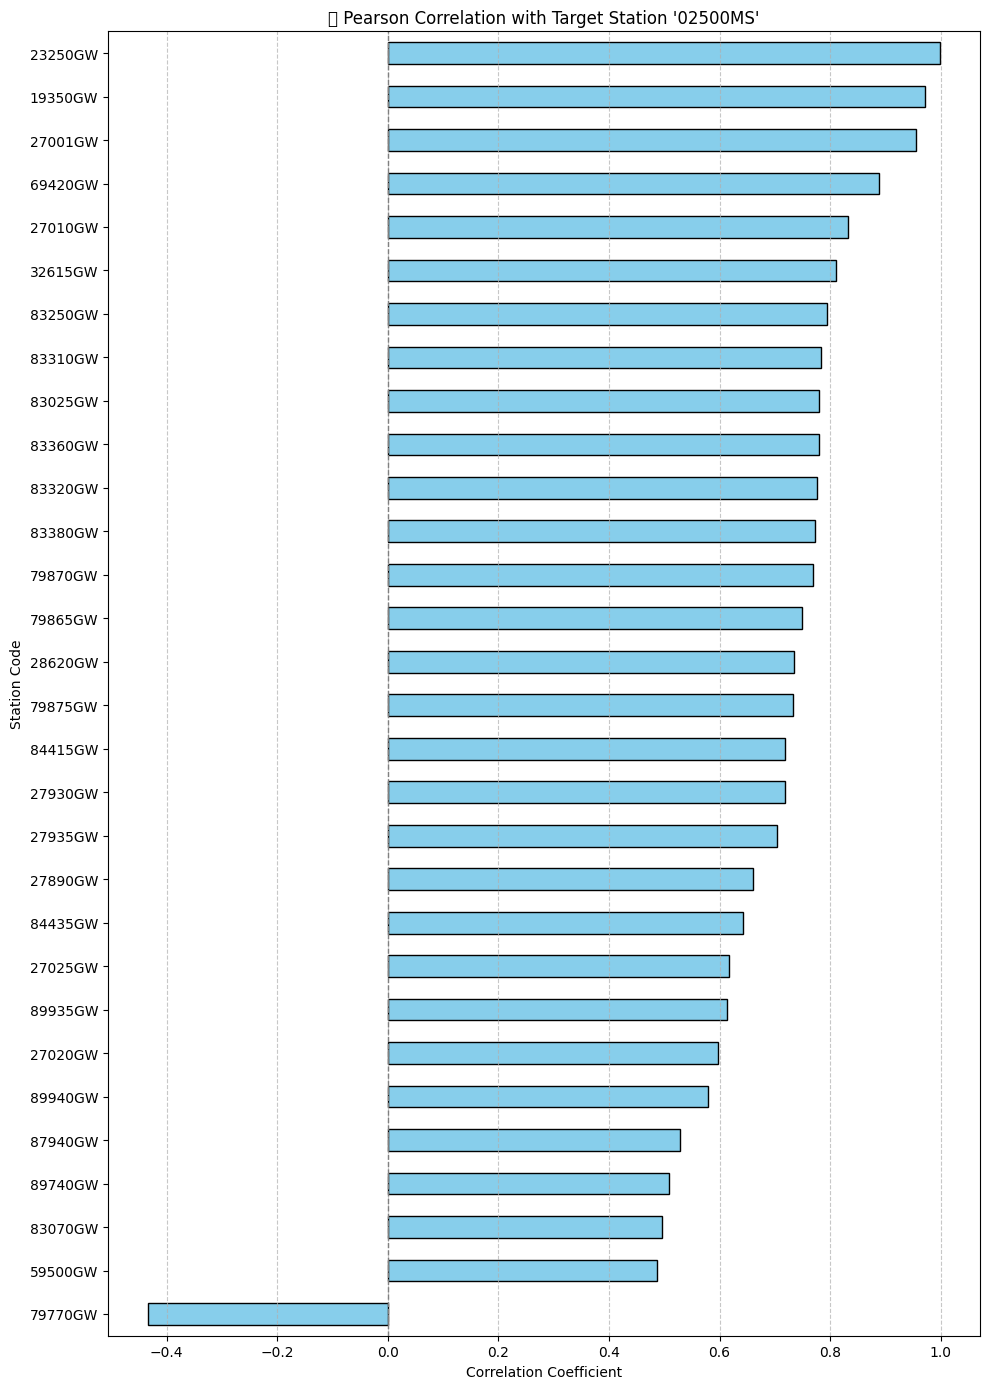

In [32]:
plt.figure(figsize=(10, 14))
correlations.sort_values().plot(kind='barh', color='skyblue', edgecolor='black')

plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)
plt.title("📈 Pearson Correlation with Target Station '02500MS'")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Station Code")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [33]:
# Step 8: Select top 2 correlated reference stations
top_refs = correlations.head(2).index.tolist()
final_df = clean_df[[target_station] + top_refs].copy()

In [34]:
top_refs

['23250GW', '19350GW']

#### Checking the final dataframe

In [35]:
final_df

station_code,23350GW,23250GW,19350GW
timestamp,,,
2023-01-11 09:00:00,21.82,23.45,7.28
2023-01-12 11:00:00,21.84,23.46,7.28
2023-01-12 12:00:00,21.84,23.46,7.28
2023-01-12 13:00:00,21.84,23.46,7.28
2023-01-12 14:00:00,21.84,23.46,7.28
...,...,...,...
2024-12-22 19:00:00,18.14,19.43,6.09
2024-12-22 20:00:00,18.14,19.43,6.09
2024-12-22 21:00:00,18.14,19.43,6.09


In [36]:
# Step 8: Build new DataFrame with target and top 3 references
top_3_refs = correlations.dropna().sort_values(ascending=False).head(3).index.tolist()
selected_stations = [target_station] + top_3_refs
pattern_df = pivot_df[selected_stations].copy()

In [37]:
pattern_df

station_code,23350GW,23250GW,19350GW,27001GW
timestamp,,,,
2023-01-01 00:00:00,21.73,23.34,7.27,35.79
2023-01-01 01:00:00,21.73,23.34,7.27,35.80
2023-01-01 02:00:00,21.73,23.34,7.26,35.80
2023-01-01 03:00:00,21.73,23.34,7.26,35.80
2023-01-01 04:00:00,21.73,23.34,7.26,35.79
...,...,...,...,...
2024-12-31 20:00:00,18.31,19.65,6.18,34.88
2024-12-31 21:00:00,18.31,19.65,6.18,34.88
2024-12-31 22:00:00,18.32,19.65,6.18,34.88


In [38]:
pattern_df.isnull().sum()

station_code
23350GW      0
23250GW      0
19350GW    158
27001GW      0
dtype: int64

In [39]:
# Check how many missing values are in station 19350GW
missing_count = pattern_df['19350GW'].isna().sum()
print(f"🔍 Missing values in station 19350GW: {missing_count}")

# Display timestamps where the values are missing
missing_timestamps = pattern_df[pattern_df['19350GW'].isna()]
print("\n📅 Timestamps with missing values in 19350GW:")
print(missing_timestamps[['19350GW']])


🔍 Missing values in station 19350GW: 158

📅 Timestamps with missing values in 19350GW:
station_code         19350GW
timestamp                   
2023-03-24 01:00:00      NaN
2023-03-24 13:00:00      NaN
2023-03-24 14:00:00      NaN
2023-03-24 15:00:00      NaN
2023-03-24 16:00:00      NaN
...                      ...
2024-12-14 08:00:00      NaN
2024-12-14 09:00:00      NaN
2024-12-14 10:00:00      NaN
2024-12-14 11:00:00      NaN
2024-12-14 12:00:00      NaN

[158 rows x 1 columns]


In [40]:
for col in pattern_df.columns:
    if pattern_df[col].isnull().sum() > 0:
        print(f"\n🔍 Missing value in station {col}:")
        print(pattern_df[pattern_df[col].isnull()][col])



🔍 Missing value in station 19350GW:
timestamp
2023-03-24 01:00:00   NaN
2023-03-24 13:00:00   NaN
2023-03-24 14:00:00   NaN
2023-03-24 15:00:00   NaN
2023-03-24 16:00:00   NaN
                       ..
2024-12-14 08:00:00   NaN
2024-12-14 09:00:00   NaN
2024-12-14 10:00:00   NaN
2024-12-14 11:00:00   NaN
2024-12-14 12:00:00   NaN
Name: 19350GW, Length: 158, dtype: float64


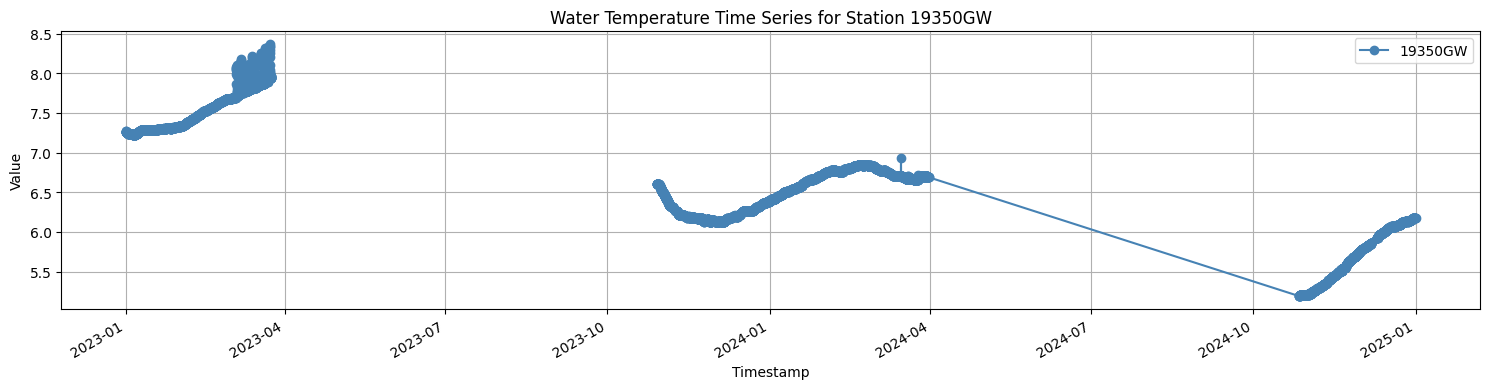

In [41]:
# Plot the time series with gaps
plt.figure(figsize=(15, 4))
pattern_df['19350GW'].plot(marker='o', linestyle='-', label='19350GW', color='steelblue')
plt.title('Water Temperature Time Series for Station 19350GW')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [42]:
# # Step 1: Identify timestamps where 19350GW has missing values
# missing_timestamps = pattern_df[pattern_df['19350GW'].isna()].index

# # Step 2: Drop those timestamps from all stations
# clean_df = pattern_df.drop(index=missing_timestamps)

# # Step 3 (optional): Verify
# print(f"✅ Removed {len(missing_timestamps)} rows from all stations.")
# print(f"Remaining rows: {len(clean_df)}")

# # Step 4 (optional): Check if NaNs still exist in 19350GW
# print(f"Remaining NaNs in 19350GW: {clean_df['19350GW'].isna().sum()}")


In [43]:
# pattern_df = clean_df

In [44]:
# pattern_df.isnull().sum()   

In [45]:
# Example: Fill NaNs in 19350GW with values from 23350GW if simple fill
pattern_df['19350GW_filled'] = pattern_df['19350GW'].fillna(pattern_df['23350GW'])


In [46]:
# subset = gauging_df[(gauging_df['sensor_code'] == 'WT') & (gauging_df['station_code'] == '51450PG')]
# subset['is_missing'] = subset['value'].isna()
# subset[['timestamp', 'is_missing']].head(20)  # Replace timestamp with your actual time column


In [47]:
print(pattern_df.columns.tolist())

['23350GW', '23250GW', '19350GW', '27001GW', '19350GW_filled']


#### Plotting target station with reference stations

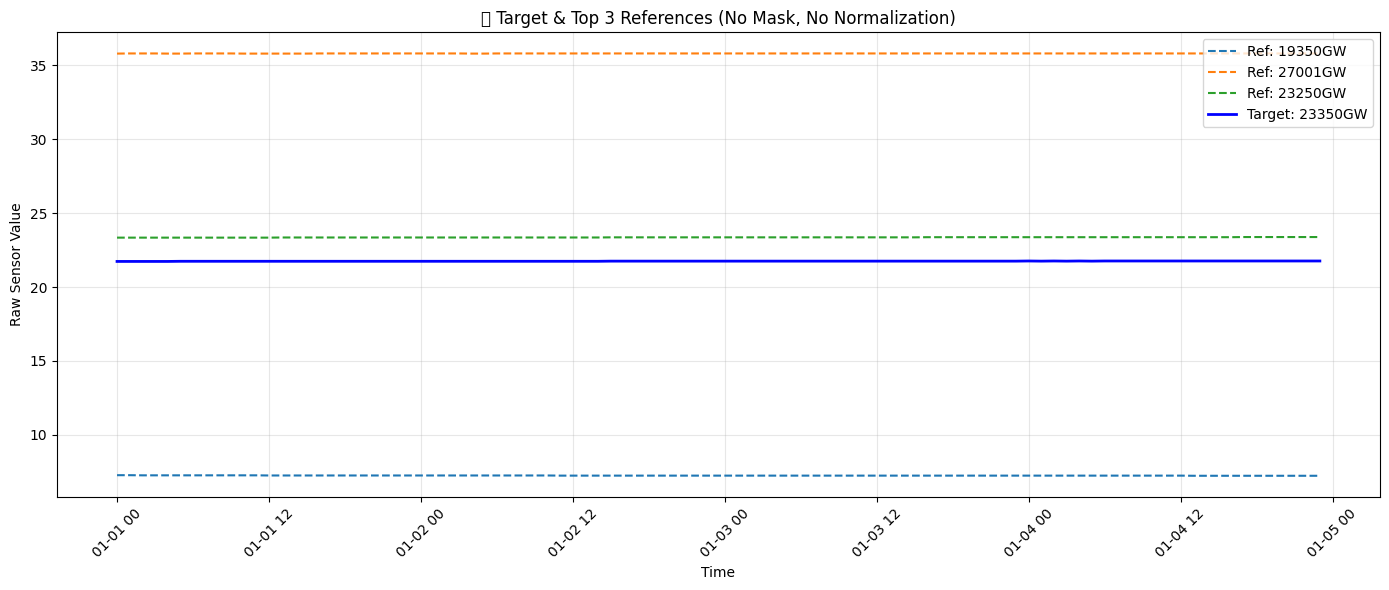

In [48]:
# Define the stations 
target = "23350GW"  # Target station
# References are the top 3 correlated stations
references = ["19350GW", "27001GW", "23250GW"]

# Define time range for plot (e.g., Jan 1 to Jan 4, 2023)
start_time = "2023-01-01"
end_time = "2023-01-04"

# Slicing the DataFrame
plot_df = pattern_df[[target] + references].loc[start_time:end_time].copy()

# Plotting
plt.figure(figsize=(14, 6))

# Plot reference series
for ref in references:
    plt.plot(plot_df.index, plot_df[ref], linestyle='--', label=f"Ref: {ref}")

# Plot target series
plt.plot(plot_df.index, plot_df[target], color='blue', linewidth=2, label=f"Target: {target}")

plt.xlabel("Time")
plt.ylabel("Raw Sensor Value")
plt.title("📍 Target & Top 3 References (No Mask, No Normalization)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# -------------------------------------------
# 🔹 STEP 1: Normalizing the Time Series Data
# -------------------------------------------

In [49]:
from sklearn.preprocessing import StandardScaler

#  Initialize the Scaler
scaler = StandardScaler()

#  Fit the scaler on the full pattern_df and transform it
normalized_array = scaler.fit_transform(pattern_df)

#  Reconstruct a DataFrame with the same shape, columns, and index
normalized_df = pd.DataFrame(
    normalized_array,
    columns=pattern_df.columns,
    index=pattern_df.index
)

# 4️⃣ Print shape and preview
print(" Normalized shape:", normalized_df.shape)
display(normalized_df.head())


 Normalized shape: (7297, 5)


station_code,23350GW,23250GW,19350GW,27001GW,19350GW_filled
timestamp,,,,,
2023-01-01 00:00:00,1.155723,1.134536,0.929330,1.114228,0.195451
2023-01-01 01:00:00,1.155723,1.134536,0.929330,1.130022,0.195451
2023-01-01 02:00:00,1.155723,1.134536,0.915029,1.130022,0.190325
2023-01-01 03:00:00,1.155723,1.134536,0.915029,1.130022,0.190325
2023-01-01 04:00:00,1.155723,1.134536,0.915029,1.114228,0.190325


# ---------------------------------------------------------
# 🔹 STEP 2: Defining function to the inject block-missing in the end
# ---------------------------------------------------------

In [50]:


def introduce_block_missing_end(series: pd.Series, block_length: int) -> Tuple[pd.Series, int, int]:
    """
    Introduce a block of NaN values at the end of a time series.

    Parameters:
        series (pd.Series): The original time series (normalized)
        block_length (int): The number of consecutive values to mask from the end

    Returns:
        masked_series (pd.Series): The modified series with NaNs
        start_idx (int): Starting index of the missing block
        end_idx (int): Ending index (exclusive) of the missing block
    """
    ts = series.copy()
    end_idx = len(ts)
    start_idx = end_idx - block_length
    ts[start_idx:end_idx] = np.nan
    return ts, start_idx, end_idx

# Inject blocks of 7 days (168 time points).

# ---------------------------------------------------------
# 🔹 STEP 2b: Applying block-missing to the normalized target series
# ---------------------------------------------------------

In [51]:
# ---------------------------------------------------------
# 🔹 STEP 2b: Apply block-missing to the normalized target series
# ---------------------------------------------------------

# Define target station 
target_station = "23350GW"

# Define block length (e.g. 10 time points ~ 5 hours if half-hourly)
block_length = 721

# Apply the masking function
masked_target, start_idx, end_idx = introduce_block_missing_end(
    normalized_df[target_station],
    block_length
)

# ✅ Optional: Print info about the block
print(f"🧱 Missing block injected from index {start_idx} to {end_idx - 1}")
print("🕓 Timestamps of missing block:\n", normalized_df.index[start_idx:end_idx])


🧱 Missing block injected from index 6576 to 7296
🕓 Timestamps of missing block:
 DatetimeIndex(['2024-12-02 00:00:00', '2024-12-02 01:00:00',
               '2024-12-02 02:00:00', '2024-12-02 03:00:00',
               '2024-12-02 04:00:00', '2024-12-02 05:00:00',
               '2024-12-02 06:00:00', '2024-12-02 07:00:00',
               '2024-12-02 08:00:00', '2024-12-02 09:00:00',
               ...
               '2024-12-31 15:00:00', '2024-12-31 16:00:00',
               '2024-12-31 17:00:00', '2024-12-31 18:00:00',
               '2024-12-31 19:00:00', '2024-12-31 20:00:00',
               '2024-12-31 21:00:00', '2024-12-31 22:00:00',
               '2024-12-31 23:00:00', '2025-01-01 00:00:00'],
              dtype='datetime64[ns]', name='timestamp', length=721, freq=None)


# ---------------------------------------------------------
# 🔹 STEP 3: Preparing NumPy arrays for imputation and evaluation
# ---------------------------------------------------------

In [52]:
# Extract the reference station names (excluding the target)
reference_stations = [col for col in normalized_df.columns if col != target_station]

#  Get reference matrix as shape (num_refs, time) — transposed
ref_matrix = normalized_df[reference_stations].to_numpy().T  # shape: (num_refs, time)

#  Get the masked target series as array (shape: time,)
masked_target_array = masked_target.to_numpy().copy()

#  Get the original (true) unmasked target series
true_target_array = normalized_df[target_station].to_numpy()

#  Save the index positions of the block-masked values
nan_block_indices = np.arange(start_idx, end_idx)

#  Preview shapes and sanity check
print(" Target shape:", masked_target_array.shape)
print(" Ref matrix shape:", ref_matrix.shape)
print(" Block indices:", nan_block_indices)
print(" Target preview (with NaNs):", masked_target_array[start_idx:end_idx])


 Target shape: (7297,)
 Ref matrix shape: (4, 7297)
 Block indices: [6576 6577 6578 6579 6580 6581 6582 6583 6584 6585 6586 6587 6588 6589
 6590 6591 6592 6593 6594 6595 6596 6597 6598 6599 6600 6601 6602 6603
 6604 6605 6606 6607 6608 6609 6610 6611 6612 6613 6614 6615 6616 6617
 6618 6619 6620 6621 6622 6623 6624 6625 6626 6627 6628 6629 6630 6631
 6632 6633 6634 6635 6636 6637 6638 6639 6640 6641 6642 6643 6644 6645
 6646 6647 6648 6649 6650 6651 6652 6653 6654 6655 6656 6657 6658 6659
 6660 6661 6662 6663 6664 6665 6666 6667 6668 6669 6670 6671 6672 6673
 6674 6675 6676 6677 6678 6679 6680 6681 6682 6683 6684 6685 6686 6687
 6688 6689 6690 6691 6692 6693 6694 6695 6696 6697 6698 6699 6700 6701
 6702 6703 6704 6705 6706 6707 6708 6709 6710 6711 6712 6713 6714 6715
 6716 6717 6718 6719 6720 6721 6722 6723 6724 6725 6726 6727 6728 6729
 6730 6731 6732 6733 6734 6735 6736 6737 6738 6739 6740 6741 6742 6743
 6744 6745 6746 6747 6748 6749 6750 6751 6752 6753 6754 6755 6756 6757
 6758 675

In [53]:
print(type(masked_target_array), masked_target_array.shape)

<class 'numpy.ndarray'> (7297,)


# -----------------------------------------------
# 🔹 STEP 4.1: Setting safe parameters for all models
# -----------------------------------------------

In [54]:
k = 5  # number of top matching sequences (for TKCMs)
l = 4  # sliding window size
rank = max(1, min(ref_matrix.shape[0] - 1, 2))  # safe low-rank dimension for SVD, TRMF


### --- Basic Imputers --

In [55]:
from sklearn.impute import SimpleImputer

# --- Basic Imputers ---

class ZeroImputer:
    def fit_transform(self, X):
        X = X.copy()
        X[np.isnan(X)] = 0
        return X


class MinImputer:
    def fit_transform(self, X):
        fill_value = np.nanmin(X[~np.isnan(X)])
        imp = SimpleImputer(strategy='constant', fill_value=fill_value)
        return imp.fit_transform(X)

class InterpolationImputer:
    def fit_transform(self, X):
        return pd.DataFrame(X).interpolate(method='linear', axis=0, limit_direction='both').values


# -----------------------------------------------
# 🔹 STEP 4.2: Applying each model with correct usage
# -----------------------------------------------

In [56]:


# Stack the masked target (first row) + full reference matrix (rest)
X_stacked = np.vstack([masked_target_array, ref_matrix])

# TKCM
tkcm = TKCM(k=k, l=l)
tkcm_imputed = tkcm.impute(masked_target_array.copy(), offset=start_idx, ref_ts=ref_matrix)

#  TKCM_PLUS
tkcm_plus = TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.5)
tkcm_plus_imputed = tkcm_plus.impute(masked_target_array.copy(), offset=start_idx, ref_ts=ref_matrix)

#  TKCM_Weighted
tkcm_w = TKCM_Weighted(k=k, l=l)
tkcm_weighted_imputed = tkcm_w.impute(masked_target_array.copy(), offset=start_idx, ref_ts=ref_matrix)

#  TKCM_PRO
tkcm_pro = TKCM_PRO(k=k, l=l)
tkcm_pro_imputed = tkcm_pro.impute(masked_target_array.copy(), offset=start_idx, ref_ts=ref_matrix)


# CDRec
cdrec = CDRec(rank=rank)
cdrec_imputed = cdrec.impute(X_stacked.copy())[0]  # Only return target row

#  DynaMMo
dynammo = DynaMMo(latent_dim=rank)
dynammo_imputed = dynammo.fit_transform(X_stacked.copy())[0]

#  SoftImpute
soft = SoftImpute(max_rank=rank)
soft_imputed = soft.fit_transform(X_stacked.copy())[0]

#  IterativeSVD
svd = IterativeSVD(rank=rank)
svd_imputed = svd.fit_transform(X_stacked.copy())[0]

#  ST_MVL
st_mvl = ST_MVL()
st_mvl_imputed = st_mvl.impute(X_stacked.copy())[0]

#  TRMF
trmf = TRMFImputer(rank=rank)
trmf_imputed = trmf.fit_transform(X_stacked.copy())[0]

#  Zero Imputer
zero_imputer = ZeroImputer()
zero_imputed = zero_imputer.fit_transform(X_stacked.copy())[0]

#  Min Imputer
min_imputer = MinImputer()
min_imputed = min_imputer.fit_transform(X_stacked.copy())[0]

#  Interpolation Imputer
interp_imputer = InterpolationImputer()
interp_imputed = interp_imputer.fit_transform(X_stacked.copy())[0]


In [57]:
# In TKCM imputation loop
missing_indices = np.where(np.isnan(masked_target_array))[0]

for offset in missing_indices:
    imputed_series = tkcm.impute(masked_target_array.copy(), offset=offset, ref_ts=ref_matrix)
    print(f"Offset {offset} → Imputed value = {imputed_series[offset]}")


Offset 6576 → Imputed value = -1.3952216999688503
Offset 6577 → Imputed value = 0.0
Offset 6578 → Imputed value = 0.0
Offset 6579 → Imputed value = 0.0
Offset 6580 → Imputed value = 0.0
Offset 6581 → Imputed value = 0.0
Offset 6582 → Imputed value = 0.0
Offset 6583 → Imputed value = 0.0
Offset 6584 → Imputed value = 0.0
Offset 6585 → Imputed value = 0.0
Offset 6586 → Imputed value = 0.0
Offset 6587 → Imputed value = 0.0
Offset 6588 → Imputed value = 0.0
Offset 6589 → Imputed value = 0.0
Offset 6590 → Imputed value = 0.0
Offset 6591 → Imputed value = 0.0
Offset 6592 → Imputed value = 0.0
Offset 6593 → Imputed value = 0.0
Offset 6594 → Imputed value = 0.0
Offset 6595 → Imputed value = 0.0
Offset 6596 → Imputed value = 0.0
Offset 6597 → Imputed value = 0.0
Offset 6598 → Imputed value = 0.0
Offset 6599 → Imputed value = 0.0
Offset 6600 → Imputed value = 0.0
Offset 6601 → Imputed value = 0.0
Offset 6602 → Imputed value = 0.0
Offset 6603 → Imputed value = 0.0
Offset 6604 → Imputed value = 0.

# ---------------------------------------------------------
# 🔹 STEP 5: Evaluating all imputation methods (END Block)
# ---------------------------------------------------------

In [58]:
results_block = []

# 🎯 True values for the missing block
true_vals = true_target_array[start_idx:end_idx]
missing_indices = np.arange(start_idx, end_idx)

# ✅ Helper to evaluate predictions against true values

def evaluate_direct(name, imputed_array):
    try:
        predicted = imputed_array[start_idx:end_idx]
        
        # Core Errors
        mae = np.mean(np.abs(predicted - true_vals))
        rmse = np.sqrt(np.mean((predicted - true_vals) ** 2))
        me = np.mean(predicted - true_vals)  # Mean Error (signed)

        # Bias-Variance
        bias = np.mean(predicted) - np.mean(true_vals)
        bias_sq = bias ** 2
        variance = np.mean((predicted - np.mean(predicted)) ** 2)

        results_block.append({
            "Method": name,
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4),
            "ME": round(me, 4),
            "Bias^2": round(bias_sq, 4),
            "Variance": round(variance, 4),
            "First Imputed": round(predicted[0], 4),
            "Last Imputed": round(predicted[-1], 4),
            "First True": round(true_vals[0], 4),
            "Last True": round(true_vals[-1], 4),
            "Missing Block": "END"
        })
    except Exception as e:
        results_block.append({
            "Method": name,
            "MAE": "NaN",
            "RMSE": "NaN",
            "ME": "NaN",
            "Bias^2": "NaN",
            "Variance": "NaN",
            "First Imputed": "NaN",
            "Last Imputed": "NaN",
            "First True": round(true_vals[0], 4),
            "Last True": round(true_vals[-1], 4),
            "Missing Block": "END"
        })

# ✅ TKCM (loop over all missing indices)
try:
    tkcm_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_imputed = TKCM(k=k, l=l).impute(tkcm_imputed, offset=offset, ref_ts=ref_matrix)
    evaluate_direct("TKCM", tkcm_imputed)
except Exception as e:
    print(" TKCM failed:", e)
    evaluate_direct("TKCM", np.full_like(true_vals, np.nan))
    
# ✅ TKCM_PLUS (loop over all missing indices)
try:
    tkcm_plus_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_plus_imputed = TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.5).impute(
            tkcm_plus_imputed, offset=offset, ref_ts=ref_matrix
        )
    evaluate_direct("TKCM_PLUS", tkcm_plus_imputed)
except Exception as e:
    print(" TKCM_PLUS failed:", e)
    evaluate_direct("TKCM_PLUS", np.full_like(true_vals, np.nan))


# ✅ TKCM_Weighted (loop over all missing indices)
try:
    tkcm_weighted_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_weighted_imputed = TKCM_Weighted(k=k, l=l).impute(tkcm_weighted_imputed, offset=offset, ref_ts=ref_matrix)
    evaluate_direct("TKCM_Weighted", tkcm_weighted_imputed)
except Exception as e:
    print(" TKCM_Weighted failed:", e)
    evaluate_direct("TKCM_Weighted", np.full_like(true_vals, np.nan))
    
# ✅ TKCM_PRO (loop over all missing indices)
try:
    tkcm_pro_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_pro_imputed = TKCM_PRO(k=k, l=l).impute(
            tkcm_pro_imputed, offset=offset, ref_ts=ref_matrix
        )
    evaluate_direct("TKCM_PRO", tkcm_pro_imputed)
except Exception as e:
    print(" TKCM_PRO failed:", e)
    evaluate_direct("TKCM_PRO", np.full_like(true_vals, np.nan))
    



# ✅ Other models (no change needed)
evaluate_direct("CDRec", cdrec_imputed)
evaluate_direct("DynaMMo", dynammo_imputed)
evaluate_direct("SoftImpute", soft_imputed)
evaluate_direct("SVDImpute", svd_imputed)

# ✅ ST_MVL — remove NaNs from references
try:
    X_stmv = X_stacked.copy()
    X_stmv[1:, :] = np.nan_to_num(X_stmv[1:, :])
    st_mvl_model = ST_MVL()
    st_mvl_imputed = st_mvl_model.impute(X_stmv)[0]
    evaluate_direct("ST_MVL", st_mvl_imputed)
except Exception as e:
    print(" ST_MVL failed:", e)
    evaluate_direct("ST_MVL", np.full_like(true_vals, np.nan))

# ✅ TRMF — fixed implementation
try:
    X_trmf_input = X_stacked.T.copy()
    observed_mask = ~np.isnan(X_stacked.T)
    X_trmf_input = np.nan_to_num(X_trmf_input, nan=0.0).astype(np.float64)
    trmf_model = TRMFImputer(rank=rank, lag_idx=[1, 2, 3])
    trmf_model.fit(X_trmf_input, observed_mask)
    X_trmf_output = trmf_model.transform()
    trmf_imputed = X_trmf_output[:, 0]
    evaluate_direct("TRMF", trmf_imputed)
except Exception as e:
    print(" TRMF failed:", e)
    evaluate_direct("TRMF", np.full_like(true_vals, np.nan))
    
evaluate_direct("Zero", zero_imputed)
evaluate_direct("Min", min_imputed)
evaluate_direct("Interpolation", interp_imputed)


# ✅ Final Results Display
results_df = pd.DataFrame(results_block)
display(results_df.style.background_gradient(cmap="YlGnBu", subset=["MAE", "RMSE", "ME", "Bias^2", "Variance"]))


,Method,MAE,RMSE,ME,Bias^2,Variance,First Imputed,Last Imputed,First True,Last True,Missing Block
0,TKCM,1.215500,1.221100,1.215500,1.477400,0.002700,-1.395200,0.000000,-1.387500,-1.034300,END
1,TKCM_PLUS,1.215500,1.221100,1.215500,1.477400,0.002700,-1.393900,0.000000,-1.387500,-1.034300,END
2,TKCM_Weighted,1.215500,1.221100,1.215500,1.477400,0.002700,-1.395100,0.000000,-1.387500,-1.034300,END
3,TKCM_PRO,1.971000,2.037100,-1.603900,2.572500,1.562500,-4.400600,-2.383600,-1.387500,-1.034300,END
4,CDRec,0.230800,0.244100,0.230800,0.053200,0.034500,-1.254500,-0.649100,-1.387500,-1.034300,END
5,DynaMMo,0.221100,0.236200,0.221100,0.048900,0.035900,-1.264000,-0.653900,-1.387500,-1.034300,END
6,SoftImpute,0.287900,0.295300,0.287900,0.082900,0.029400,-1.207500,-0.624100,-1.387500,-1.034300,END
7,SVDImpute,0.227100,0.242600,0.227100,0.051600,0.036700,-1.259400,-0.649000,-1.387500,-1.034300,END
8,ST_MVL,1.687800,2.781700,1.687800,2.848500,4.674900,-0.568300,-0.363300,-1.387500,-1.034300,END
9,TRMF,0.660900,0.661600,0.660900,0.436800,0.014100,-0.761800,-0.340800,-1.387500,-1.034300,END


- MAE (Mean Absolute Error): Average of absolute differences between predicted and true values — lower is better for consistent imputation.
- RMSE (Root Mean Squared Error): Penalizes larger errors more heavily than MAE — lower means fewer extreme errors.
- ME (Mean Error): Shows systematic over- or under-estimation — close to 0 means no consistent bias.
- Bias²: Squared mean error (systematic error); contributes to RMSE — should be low for accurate central tendency.
- Variance: Error variability across samples — lower variance means more stable predictions.

### Simulating a dataset similar to the context of my imputation results

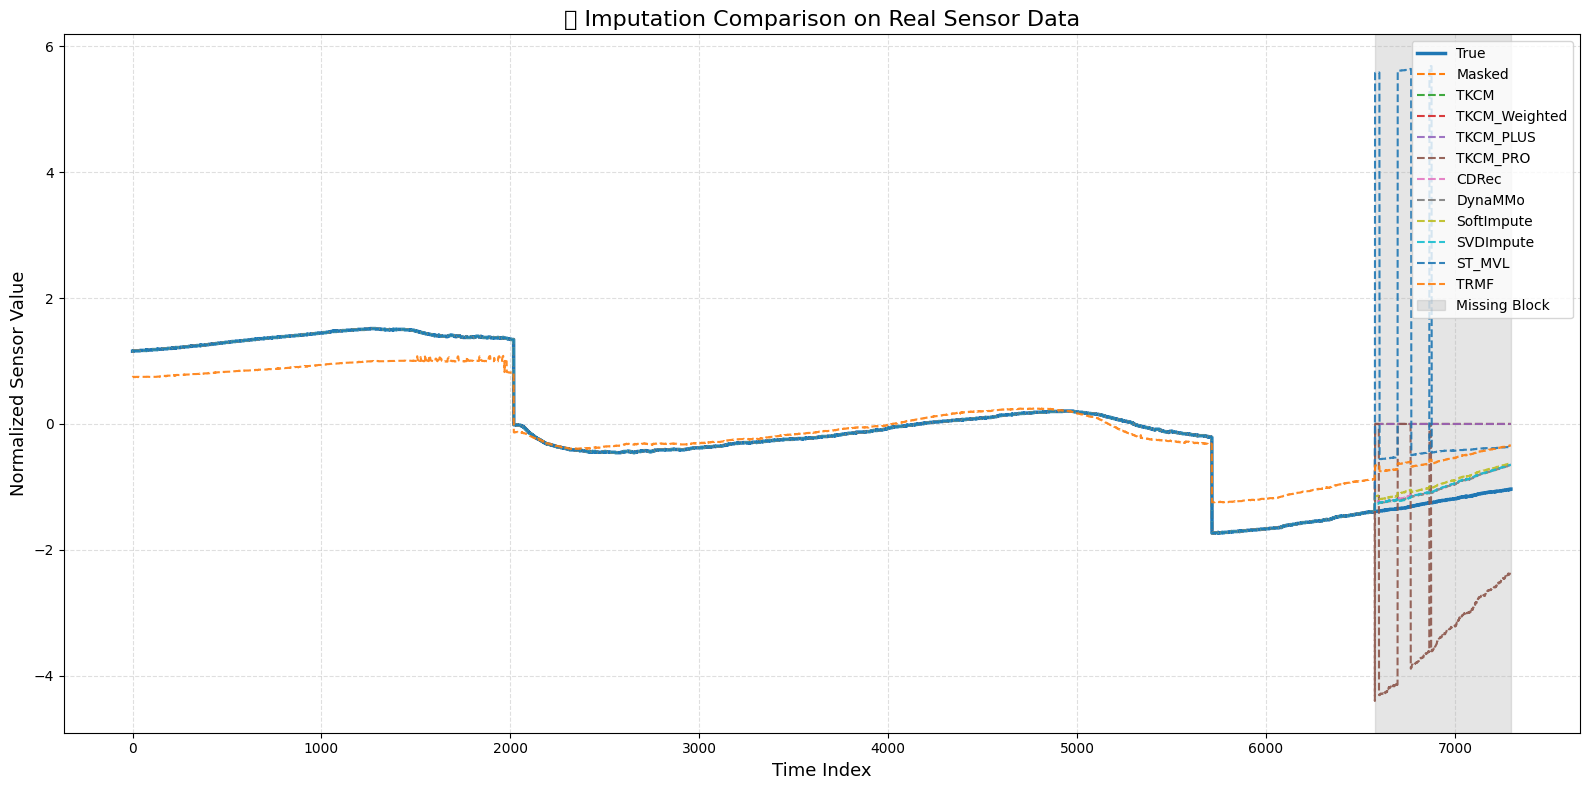

In [59]:
# Define time axis using the full length of the time series
time = np.arange(len(true_target_array))

# ✅ Imputation results dictionary (same order as benchmark)
imputed_data_real = {
    "True": true_target_array,
    "Masked": masked_target_array,
    "TKCM": tkcm_imputed,
    "TKCM_Weighted": tkcm_weighted_imputed,
    "TKCM_PLUS": tkcm_plus_imputed,
    "TKCM_PRO": tkcm_pro_imputed,
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed,
}

# ✅ Plotting
plt.figure(figsize=(16, 8))

for method, series in imputed_data_real.items():
    # Highlight 'True' as bold solid, others as dashed
    linestyle = "-" if method == "True" else "--"
    linewidth = 2.5 if method == "True" else 1.5
    alpha = 1.0 if method in {"True", "Masked"} else 0.9
    
    plt.plot(time, series, label=method, linestyle=linestyle, linewidth=linewidth, alpha=alpha)

# ✅ Highlight missing block visually
plt.axvspan(start_idx, end_idx, color="gray", alpha=0.2, label="Missing Block")

# ✅ Labels and visual styling
plt.title("🧠 Imputation Comparison on Real Sensor Data", fontsize=16)
plt.xlabel("Time Index", fontsize=13)
plt.ylabel("Normalized Sensor Value", fontsize=13)
plt.legend(loc="upper right", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


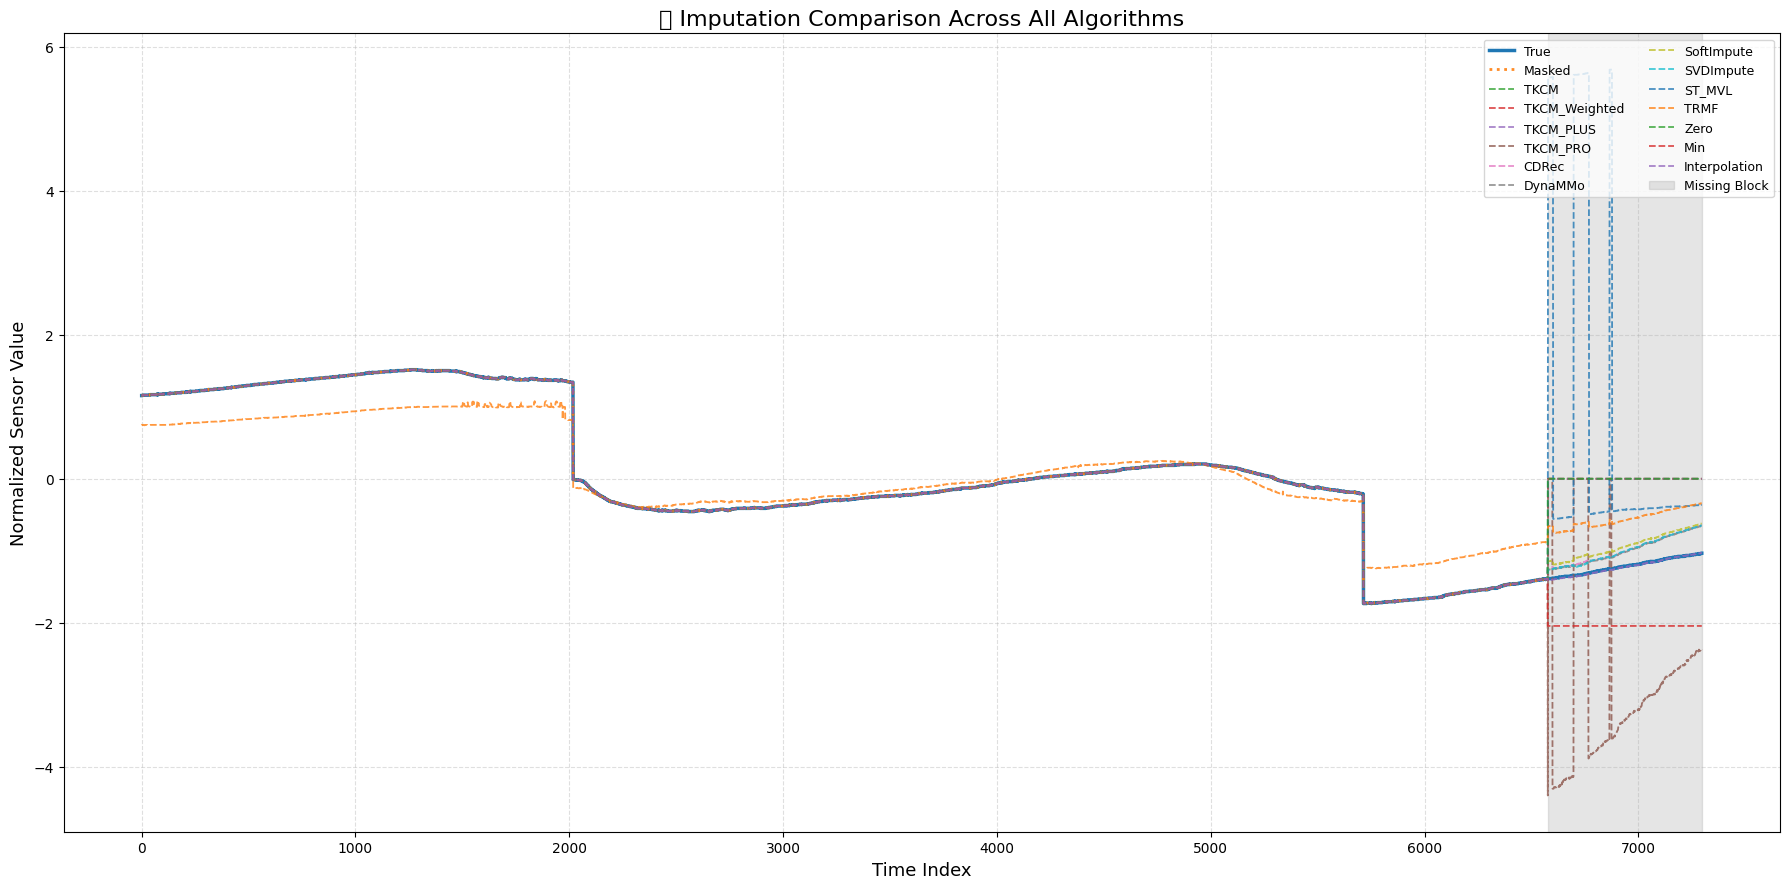

In [60]:

# Time axis based on the full target array
time = np.arange(len(true_target_array))

# Full dictionary of imputed results including basic imputers
imputed_data_real = {
    "True": true_target_array,
    "Masked": masked_target_array,
    "TKCM": tkcm_imputed,
    "TKCM_Weighted": tkcm_weighted_imputed,
    "TKCM_PLUS": tkcm_plus_imputed,
    "TKCM_PRO": tkcm_pro_imputed,
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed,
    "Zero": zero_imputed,
    "Min": min_imputed,
    "Interpolation": interp_imputed,
}

# ✅ Plotting
plt.figure(figsize=(18, 9))

for method, series in imputed_data_real.items():
    # Visual distinction
    if method == "True":
        linestyle = "-"
        linewidth = 2.5
        alpha = 1.0
    elif method == "Masked":
        linestyle = ":"
        linewidth = 2
        alpha = 0.9
    else:
        linestyle = "--"
        linewidth = 1.3
        alpha = 0.8

    plt.plot(time, series, label=method, linestyle=linestyle, linewidth=linewidth, alpha=alpha)

# ✅ Highlight the missing block
plt.axvspan(start_idx, end_idx, color="gray", alpha=0.2, label="Missing Block")

# ✅ Labels and layout
plt.title("🧠 Imputation Comparison Across All Algorithms", fontsize=16)
plt.xlabel("Time Index", fontsize=13)
plt.ylabel("Normalized Sensor Value", fontsize=13)
plt.legend(loc="upper right", fontsize=9, ncol=2)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


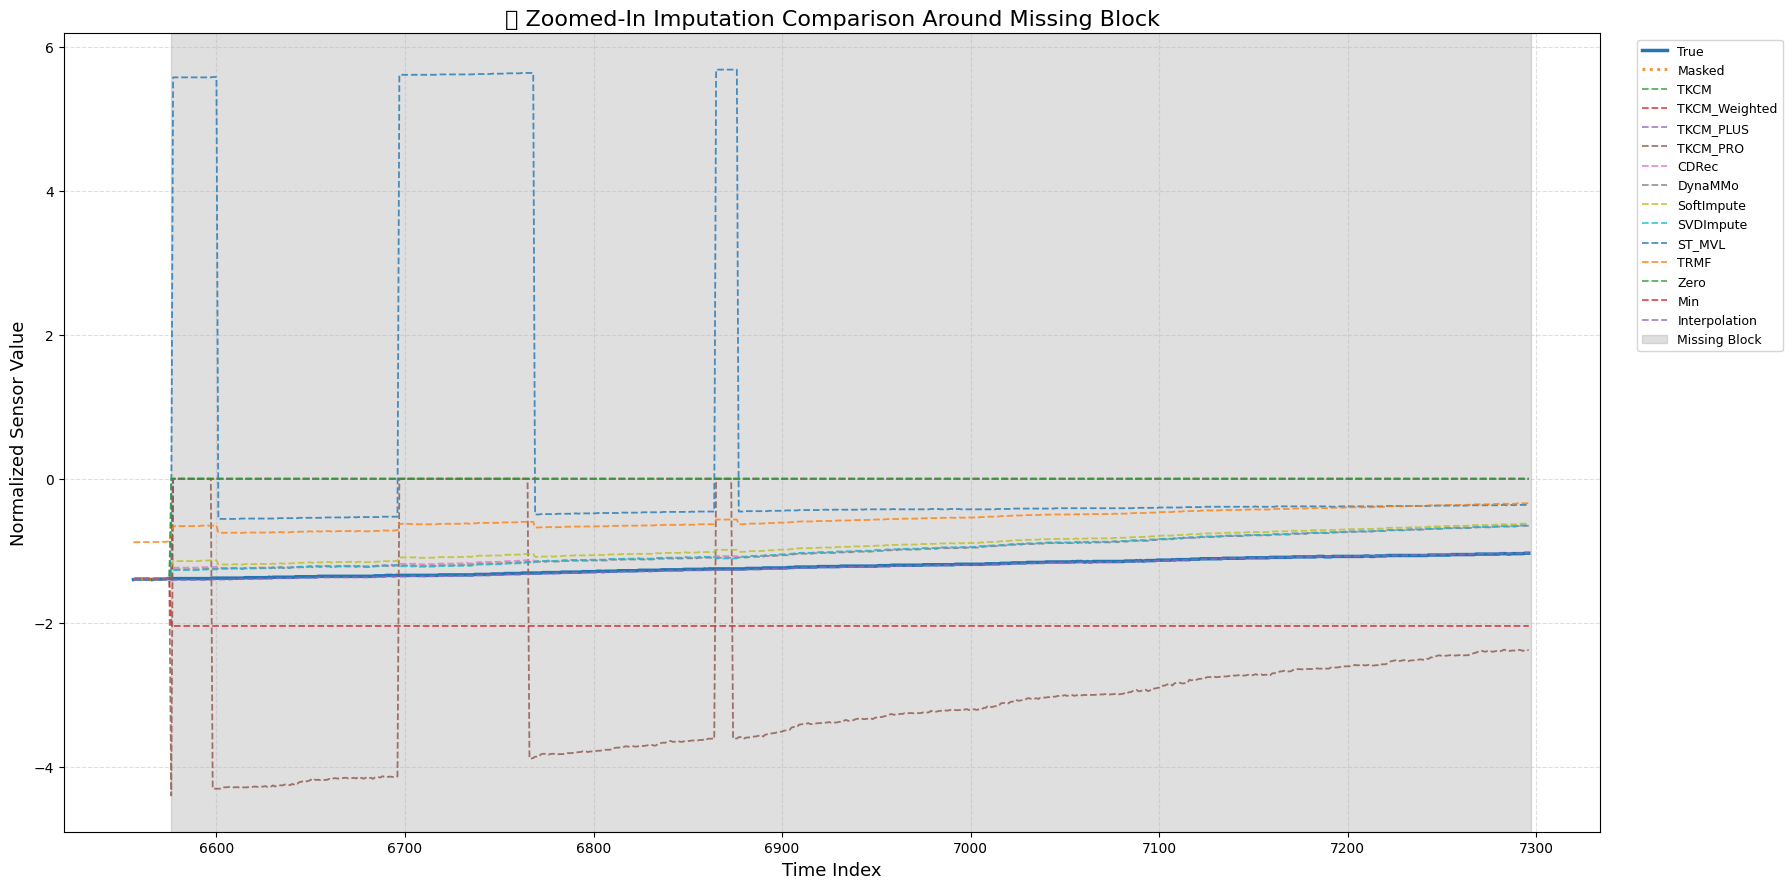

In [61]:
# ✅ Define zoom window around the missing block
zoom_start = max(0, start_idx - 20)
zoom_end = min(len(true_target_array), end_idx + 20)
time_zoom = np.arange(zoom_start, zoom_end)

# ✅ Prepare zoomed slices for all methods including basic imputers
imputed_data_zoom = {
    "True": true_target_array[zoom_start:zoom_end],
    "Masked": masked_target_array[zoom_start:zoom_end],
    "TKCM": tkcm_imputed[zoom_start:zoom_end],
    "TKCM_Weighted": tkcm_weighted_imputed[zoom_start:zoom_end],
    "TKCM_PLUS": tkcm_plus_imputed[zoom_start:zoom_end],
    "TKCM_PRO": tkcm_pro_imputed[zoom_start:zoom_end],
    "CDRec": cdrec_imputed[zoom_start:zoom_end],
    "DynaMMo": dynammo_imputed[zoom_start:zoom_end],
    "SoftImpute": soft_imputed[zoom_start:zoom_end],
    "SVDImpute": svd_imputed[zoom_start:zoom_end],
    "ST_MVL": st_mvl_imputed[zoom_start:zoom_end],
    "TRMF": trmf_imputed[zoom_start:zoom_end],
    "Zero": zero_imputed[zoom_start:zoom_end],
    "Min": min_imputed[zoom_start:zoom_end],
    "Interpolation": interp_imputed[zoom_start:zoom_end],
}

# ✅ Plotting
plt.figure(figsize=(18, 9))

for method, series in imputed_data_zoom.items():
    # Styling logic
    if method == "True":
        linestyle = "-"
        linewidth = 2.5
        alpha = 1.0
    elif method == "Masked":
        linestyle = ":"
        linewidth = 2.0
        alpha = 0.9
    else:
        linestyle = "--"
        linewidth = 1.3
        alpha = 0.8

    plt.plot(time_zoom, series, label=method, linestyle=linestyle, linewidth=linewidth, alpha=alpha)

# ✅ Highlight the missing block area
plt.axvspan(start_idx, end_idx, color="gray", alpha=0.25, label="Missing Block")

# ✅ Labels and layout
plt.title("🔍 Zoomed-In Imputation Comparison Around Missing Block", fontsize=16)
plt.xlabel("Time Index", fontsize=13)
plt.ylabel("Normalized Sensor Value", fontsize=13)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


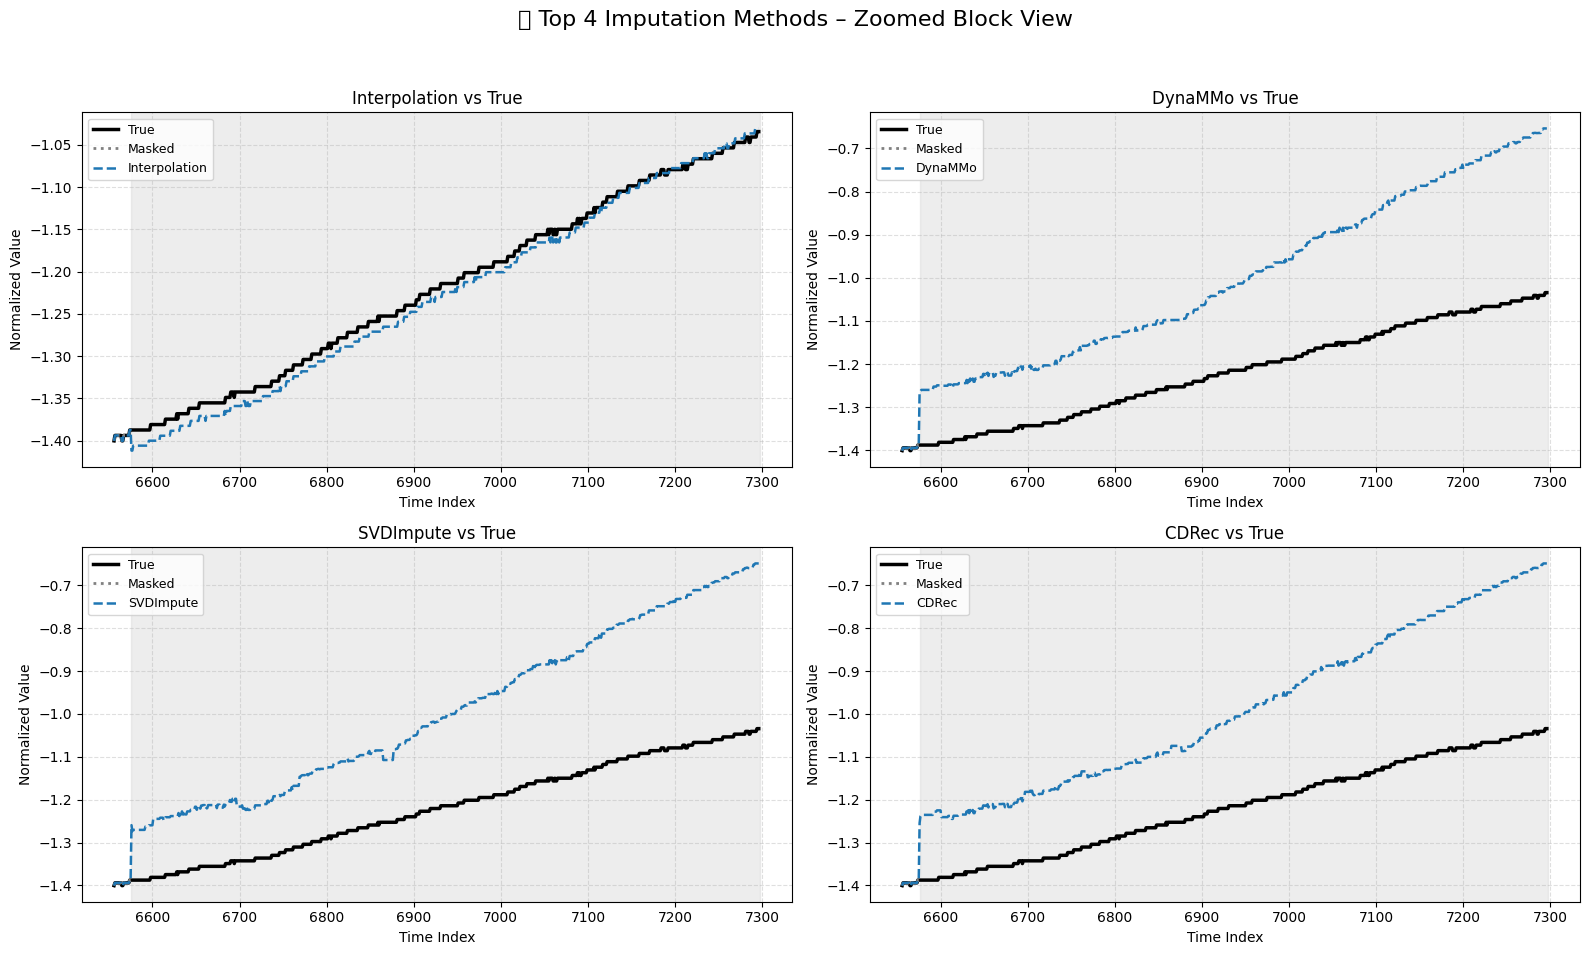

In [62]:

# ✅ Mapping method names to imputed arrays
imputed_series_map = {
    "TKCM": tkcm_imputed,
    "TKCM_Weighted": tkcm_weighted_imputed,
    "TKCM_PLUS": tkcm_plus_imputed,
    "TKCM_PRO": tkcm_pro_imputed,
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed,
    "Zero": zero_imputed,
    "Min": min_imputed,
    "Interpolation": interp_imputed,
}

# ✅ Get top 4 methods by RMSE (excluding "True" and "Masked")
top_methods = results_df.sort_values(by="RMSE")["Method"].tolist()
top_methods = [m for m in top_methods if m not in ["True", "Masked"]][:4]

# ✅ Define zoom window
zoom_start = max(0, start_idx - 20)
zoom_end = min(len(true_target_array), end_idx + 20)
time_zoom = np.arange(zoom_start, zoom_end)

# ✅ 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
axs = axs.flatten()

for i, method in enumerate(top_methods):
    ax = axs[i]

    # Plot True
    ax.plot(time_zoom, true_target_array[zoom_start:zoom_end], 
            label="True", color="black", linewidth=2.5)

    # Plot Masked
    ax.plot(time_zoom, masked_target_array[zoom_start:zoom_end], 
            label="Masked", color="gray", linestyle=":", linewidth=2)

    # Plot imputed method
    if method in imputed_series_map:
        ax.plot(time_zoom, imputed_series_map[method][zoom_start:zoom_end], 
                label=method, linestyle="--", linewidth=1.8)

    # Highlight missing block
    ax.axvspan(start_idx, end_idx, color="lightgray", alpha=0.4)

    # Formatting
    ax.set_title(f"{method} vs True", fontsize=12)
    ax.set_xlabel("Time Index", fontsize=10)
    ax.set_ylabel("Normalized Value", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)

# ✅ Global title and layout
plt.suptitle("🔍 Top 4 Imputation Methods – Zoomed Block View", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


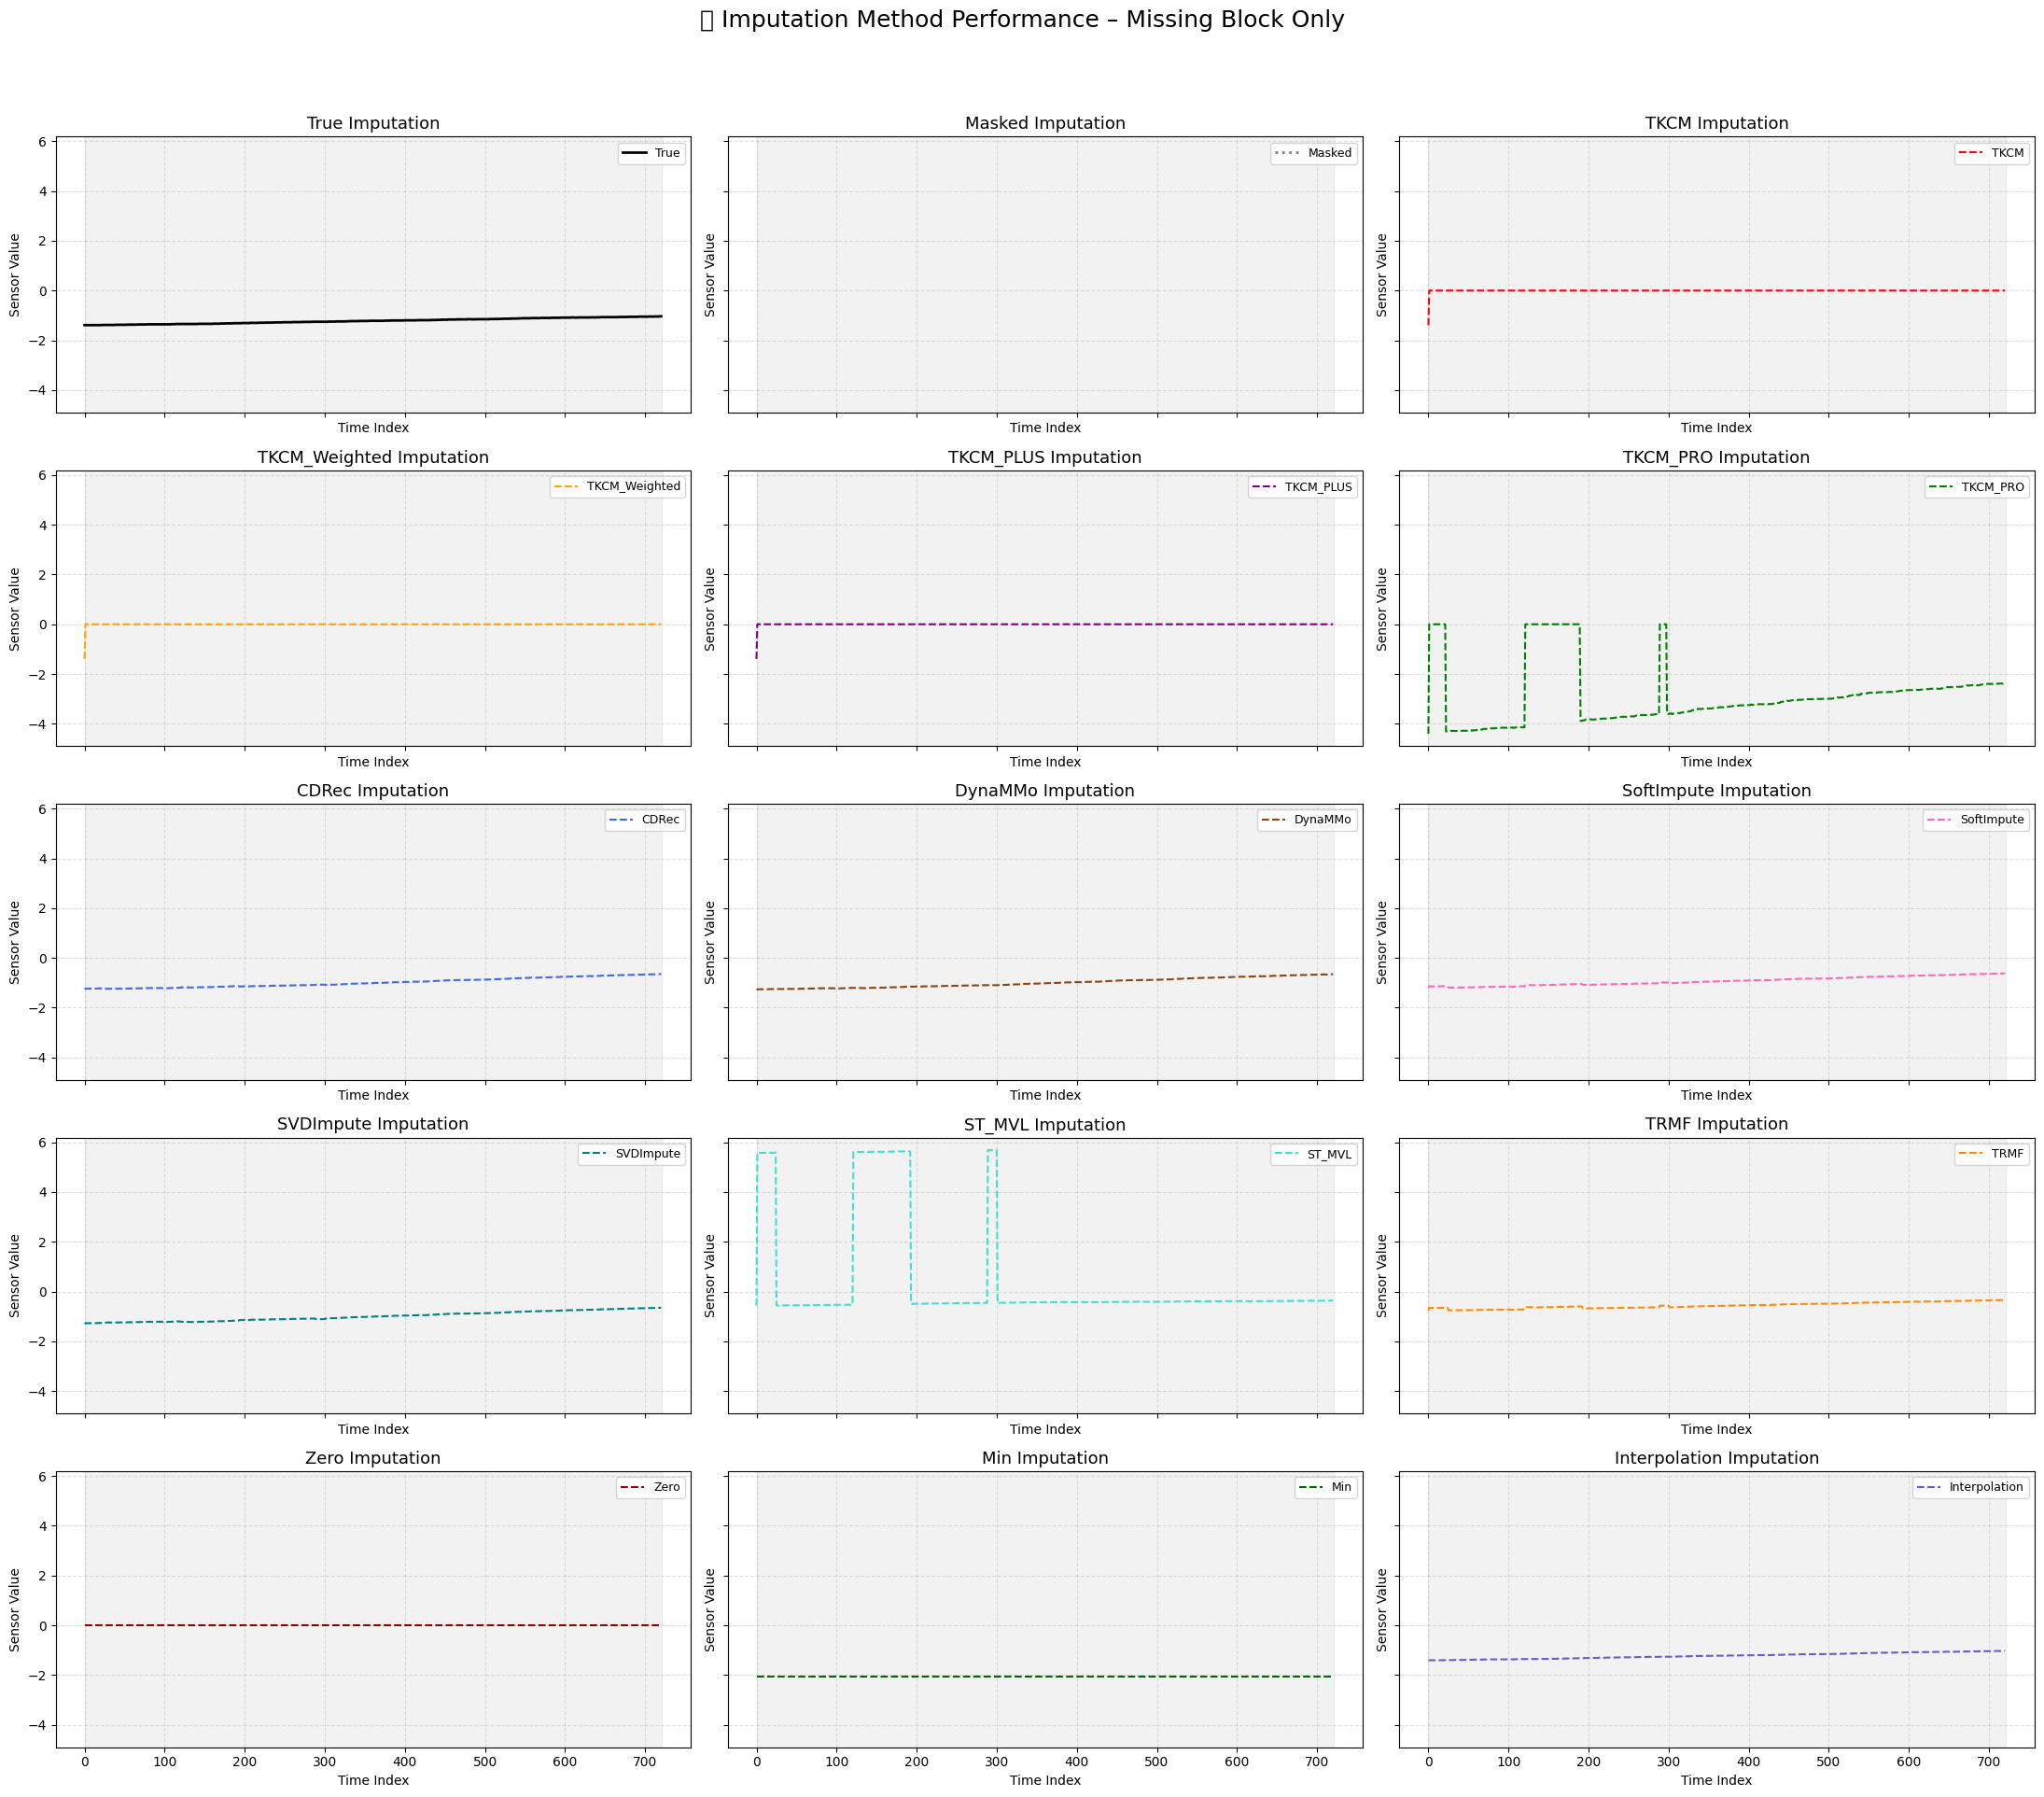

In [63]:
# 1️⃣ Define the real missing block range
block_start = start_idx
block_end = end_idx
block_length = block_end - block_start
time_block = np.arange(block_length)

# 2️⃣ Build a mapping with only the imputed block per method
imputed_data_block = {
    "True": true_target_array[block_start:block_end],
    "Masked": masked_target_array[block_start:block_end],
    "TKCM": tkcm_imputed[block_start:block_end],
    "TKCM_Weighted": tkcm_weighted_imputed[block_start:block_end],
    "TKCM_PLUS": tkcm_plus_imputed[block_start:block_end],
    "TKCM_PRO": tkcm_pro_imputed[block_start:block_end],
    "CDRec": cdrec_imputed[block_start:block_end],
    "DynaMMo": dynammo_imputed[block_start:block_end],
    "SoftImpute": soft_imputed[block_start:block_end],
    "SVDImpute": svd_imputed[block_start:block_end],
    "ST_MVL": st_mvl_imputed[block_start:block_end],
    "TRMF": trmf_imputed[block_start:block_end],
    "Zero": zero_imputed[block_start:block_end],
    "Min": min_imputed[block_start:block_end],
    "Interpolation": interp_imputed[block_start:block_end],
}

# 3️⃣ Plot settings
num_plots = len(imputed_data_block)
cols = 3
rows = (num_plots + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(22, 4 * rows), sharex=True, sharey=True)
axes = axes.flatten()

# 4️⃣ Optional color and linestyle configs
linestyles = {
    "True": "-",
    "Masked": ":"
}

colors = {
    "True": "black",
    "Masked": "gray",
    "TKCM": "red",
    "TKCM_Weighted": "orange",
    "TKCM_PLUS": "purple",
    "TKCM_PRO": "green",
    "CDRec": "royalblue",
    "DynaMMo": "saddlebrown",
    "SoftImpute": "hotpink",
    "SVDImpute": "teal",
    "ST_MVL": "turquoise",
    "TRMF": "darkorange",
    "Zero": "darkred",
    "Min": "darkgreen",
    "Interpolation": "slateblue"
}

# 5️⃣ Plot each method’s block
for i, (method, series) in enumerate(imputed_data_block.items()):
    ax = axes[i]
    ax.plot(
        time_block, series,
        label=method,
        linestyle=linestyles.get(method, "--"),
        linewidth=2 if method in ["True", "Masked"] else 1.5,
        color=colors.get(method, "gray")
    )
    ax.axvspan(0, block_length, color="gray", alpha=0.1)
    ax.set_title(f"{method} Imputation", fontsize=13)
    ax.set_xlabel("Time Index", fontsize=10)
    ax.set_ylabel("Sensor Value", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc="upper right", fontsize=9)

# 6️⃣ Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 7️⃣ Final layout
fig.suptitle("📊 Imputation Method Performance – Missing Block Only", fontsize=18)
plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()


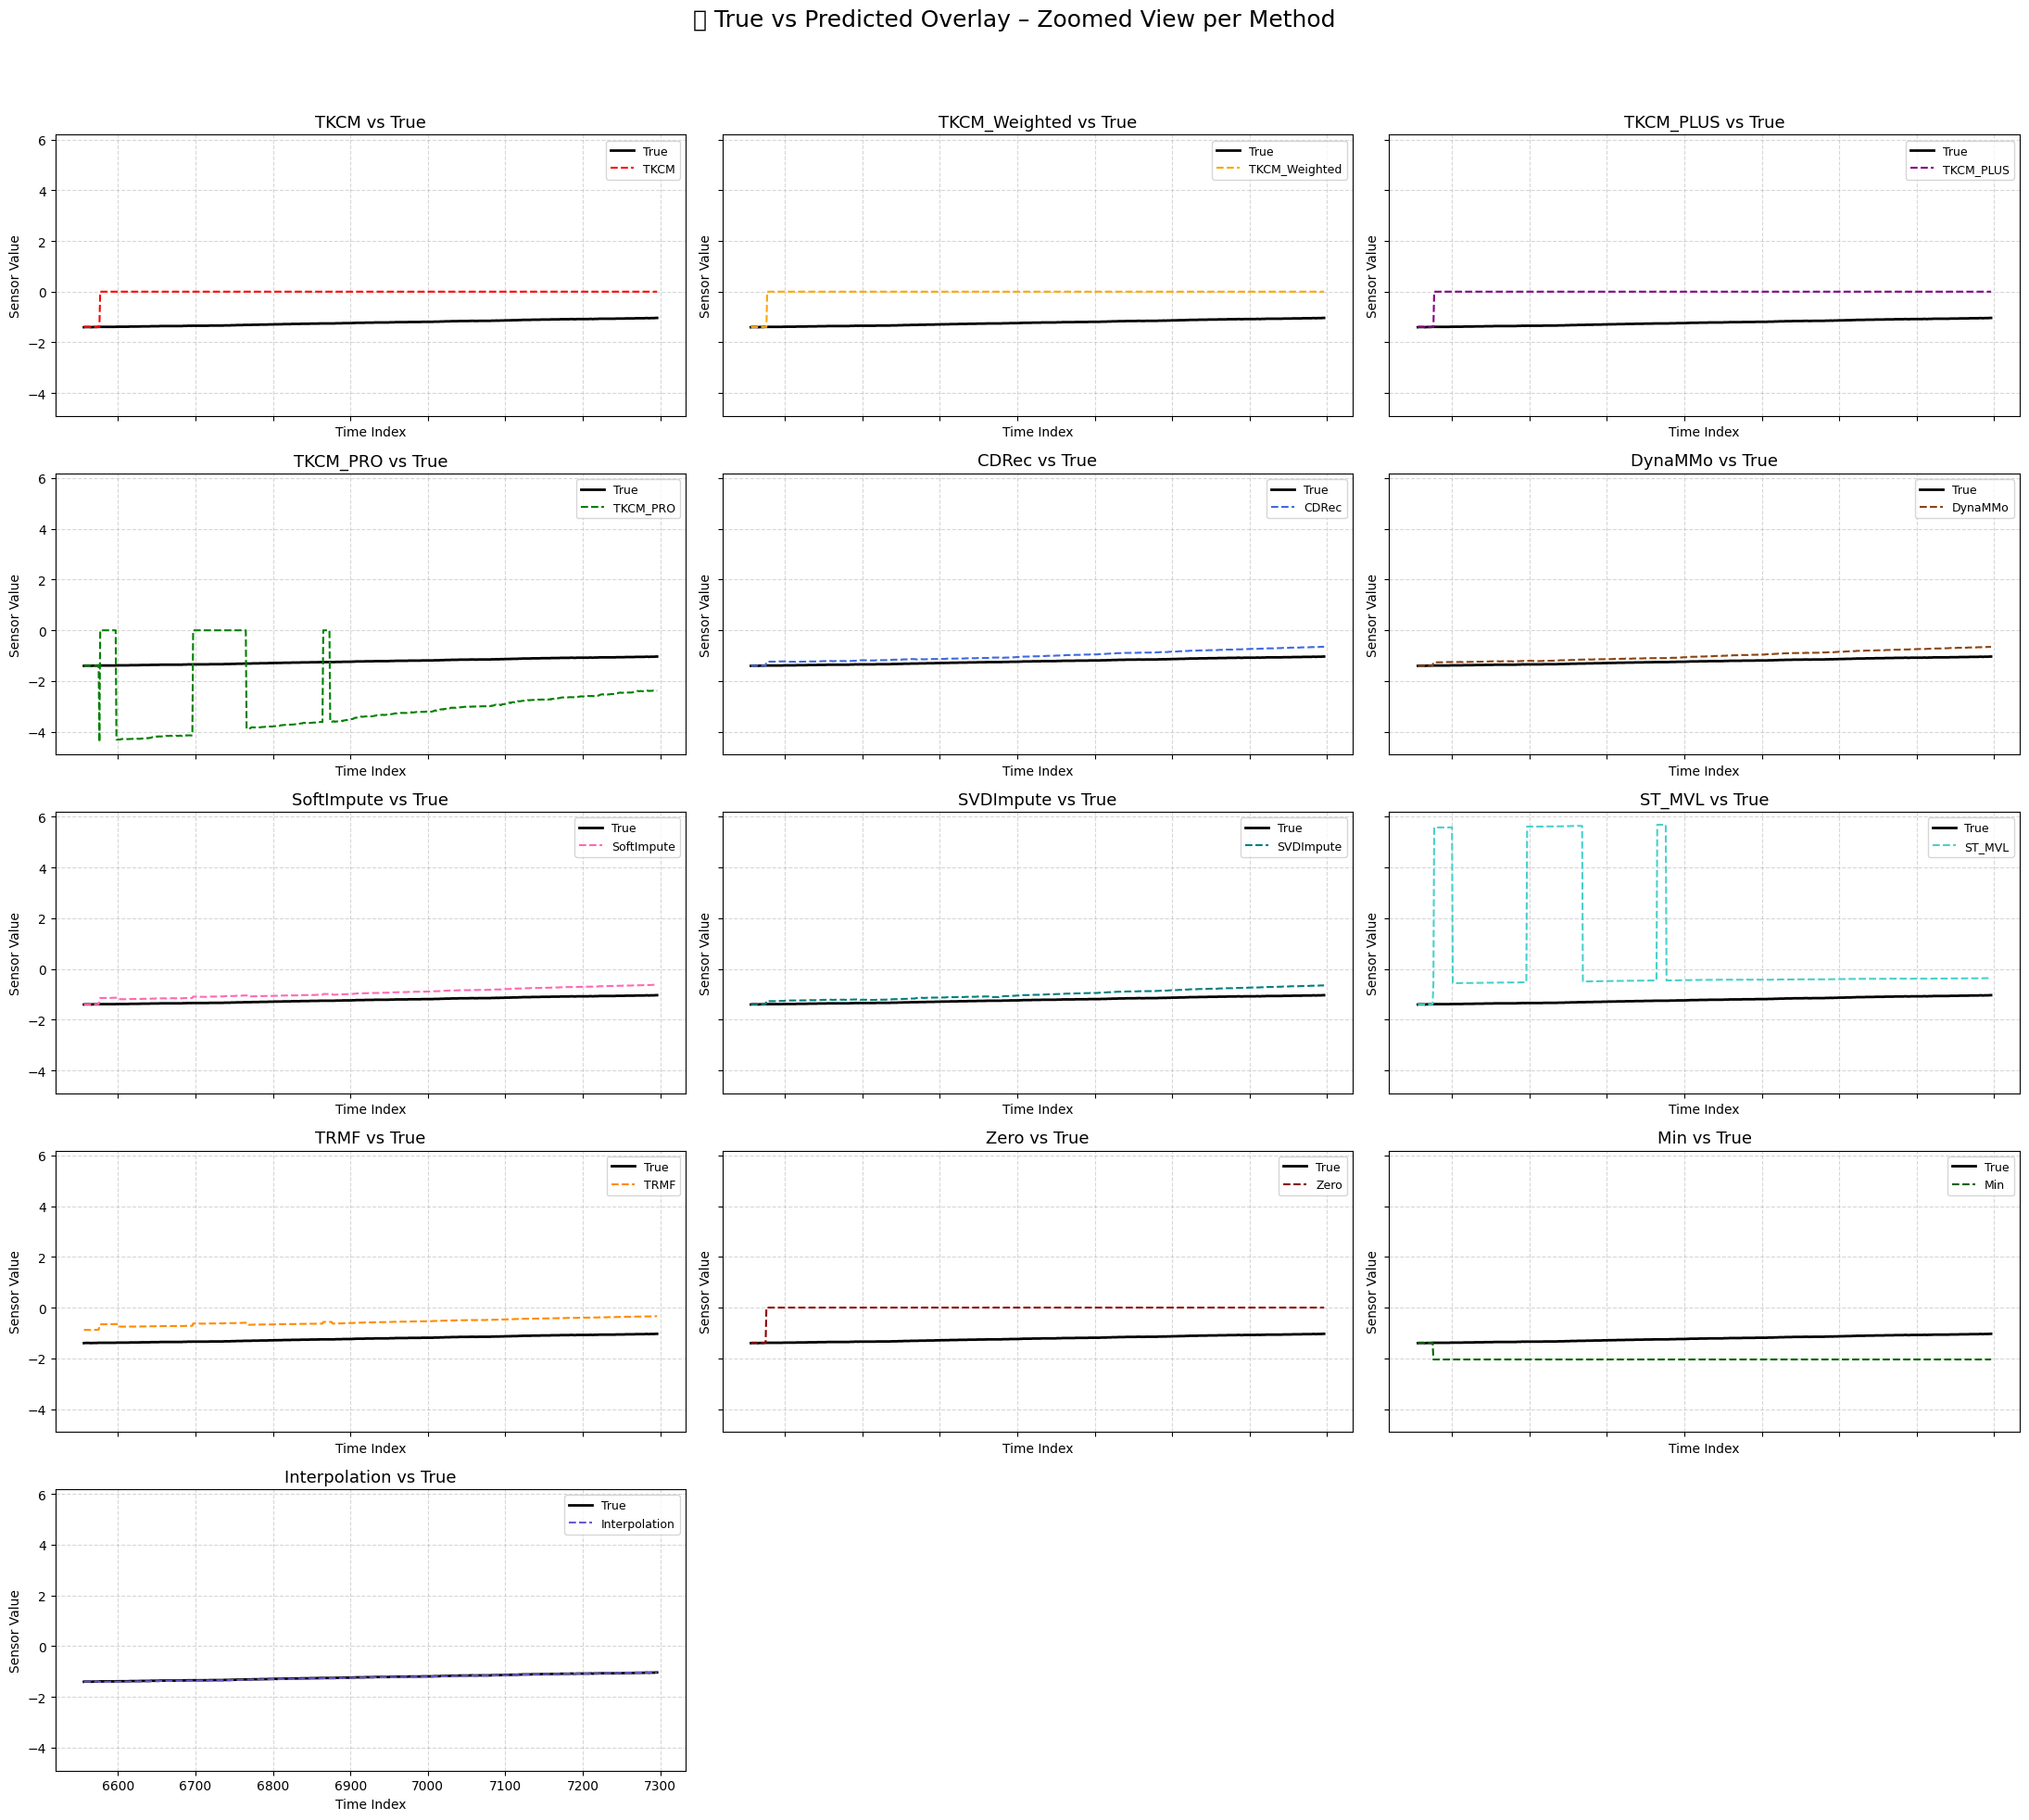

In [64]:
# 1️⃣ Time axis for full-length series
time = np.arange(len(true_target_array))

# 2️⃣ Zoomed window around missing block
zoom_start = max(0, start_idx - 20)
zoom_end = min(len(true_target_array), end_idx + 20)
time_zoom = np.arange(zoom_start, zoom_end)

# 3️⃣ Mapping: method name → imputed full series
imputed_data_overlay = {
    "TKCM": tkcm_imputed,
    "TKCM_Weighted": tkcm_weighted_imputed,
    "TKCM_PLUS": tkcm_plus_imputed,
    "TKCM_PRO": tkcm_pro_imputed,
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed,
    "Zero": zero_imputed,
    "Min": min_imputed,
    "Interpolation": interp_imputed,
}

# 4️⃣ Plot layout
num_plots = len(imputed_data_overlay)
cols = 3
rows = (num_plots + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(22, 4 * rows), sharex=True, sharey=True)
axes = axes.flatten()

# 5️⃣ Custom color mapping
colors = {
    "TKCM": "red",
    "TKCM_Weighted": "orange",
    "TKCM_PLUS": "purple",
    "TKCM_PRO": "green",
    "CDRec": "royalblue",
    "DynaMMo": "saddlebrown",
    "SoftImpute": "hotpink",
    "SVDImpute": "teal",
    "ST_MVL": "mediumturquoise",
    "TRMF": "darkorange",
    "Zero": "darkred",
    "Min": "darkgreen",
    "Interpolation": "slateblue",
}

# 6️⃣ Plot each overlay: True vs method
for i, (method, imputed_series) in enumerate(imputed_data_overlay.items()):
    ax = axes[i]

    # Plot ground truth
    ax.plot(time[zoom_start:zoom_end], true_target_array[zoom_start:zoom_end],
            label="True", color="black", linewidth=2)

    # Plot imputed series
    ax.plot(time[zoom_start:zoom_end], imputed_series[zoom_start:zoom_end],
            label=method,
            linestyle="--",
            linewidth=1.5,
            color=colors.get(method, "gray"))

    # Title and style
    ax.set_title(f"{method} vs True", fontsize=13)
    ax.set_xlabel("Time Index", fontsize=10)
    ax.set_ylabel("Sensor Value", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(fontsize=9)

# 7️⃣ Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 8️⃣ Final layout and title
plt.suptitle("✅ True vs Predicted Overlay – Zoomed View per Method", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


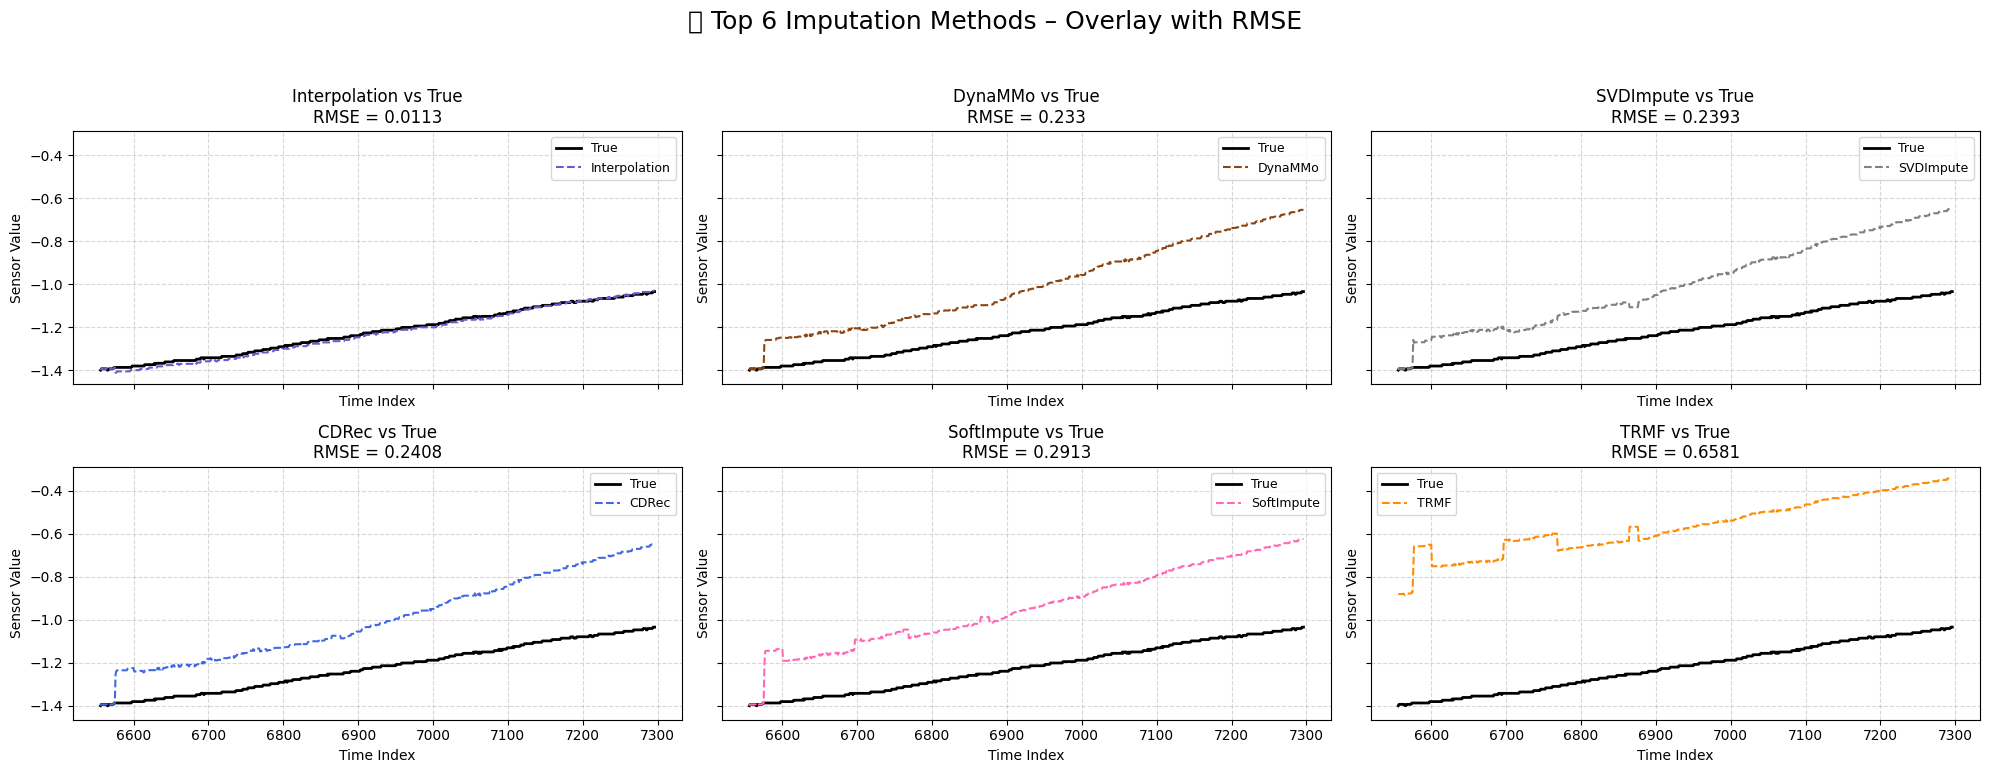

In [65]:
# ===== CONFIGURATION =====
top_k = 6            # Number of methods to display
sort_order = "asc"   # "asc" for best RMSE, "desc" for worst RMSE

# ===== FILTER TOP/BOTTOM K BASED ON RMSE =====
results_sorted = results_df.sort_values(by="RMSE", ascending=(sort_order == "asc"))
methods_to_plot = [m for m in results_sorted["Method"] if m not in ["True", "Masked"]][:top_k]

# ===== ZOOM WINDOW AROUND MISSING BLOCK =====
zoom_start = max(0, start_idx - 20)
zoom_end = min(len(true_target_array), end_idx + 20)
time = np.arange(len(true_target_array))
time_zoom = time[zoom_start:zoom_end]

# ===== FULL MAP OF IMPUTED SERIES (ADVANCED + BASIC) =====
imputed_data_overlay = {
    "TKCM": tkcm_imputed,
    "TKCM_Weighted": tkcm_weighted_imputed,
    "TKCM_PLUS": tkcm_plus_imputed,
    "TKCM_PRO": tkcm_pro_imputed,
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed,
    "Zero": zero_imputed,
    "Min": min_imputed,
    "Interpolation": interp_imputed,
}

# ===== COLOR MAP (OPTIONAL, EXPANDED) =====
colors = {
    "TKCM": "red",
    "TKCM_Weighted": "orange",
    "TKCM_PLUS": "purple",
    "TKCM_PRO": "green",
    "CDRec": "royalblue",
    "DynaMMo": "saddlebrown",
    "SoftImpute": "hotpink",
    "SVDImpute": "gray",
    "ST_MVL": "mediumturquoise",
    "TRMF": "darkorange",
    "Zero": "darkred",
    "Min": "darkgreen",
    "Interpolation": "slateblue",
}

# ===== PLOT CONFIGURATION =====
cols = 3
rows = (len(methods_to_plot) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows), sharex=True, sharey=True)
axes = axes.flatten()

# ===== PLOTTING LOOP =====
for i, method in enumerate(methods_to_plot):
    ax = axes[i]
    
    pred = imputed_data_overlay[method][zoom_start:zoom_end]
    true = true_target_array[zoom_start:zoom_end]

    # 💡 Compute RMSE only in the zoom window
    rmse = round(np.sqrt(np.mean((pred - true) ** 2)), 4)

    # 📈 Plot True vs Predicted
    ax.plot(time_zoom, true, label="True", color="black", linewidth=2)
    ax.plot(time_zoom, pred, label=method, linestyle="--", linewidth=1.5, color=colors.get(method, "gray"))

    # 🎯 Title with RMSE
    ax.set_title(f"{method} vs True\nRMSE = {rmse}", fontsize=12)
    ax.set_xlabel("Time Index", fontsize=10)
    ax.set_ylabel("Sensor Value", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(fontsize=9)

# ===== REMOVE UNUSED SUBPLOTS =====
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# ===== FINAL TITLE =====
title_msg = "Top" if sort_order == "asc" else "Bottom"
plt.suptitle(f"📊 {title_msg} {top_k} Imputation Methods – Overlay with RMSE", fontsize=18)
plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()


In [66]:
# --- Manual Grid for TKCM_PLUS and TKCM_PRO (End Block Imputation) ---
results_block = []

# ===== Manual parameter selection =====
k = 12
l = 10
alpha = 0.9
beta = 0.5

# ===== Ground truth for block =====
true_vals = true_target_array[start_idx:end_idx]
missing_indices = np.arange(start_idx, end_idx)

# ===== Helper to evaluate prediction quality =====
def evaluate_direct(name, imputed_array):
    try:
        predicted = imputed_array[start_idx:end_idx]
        mae = np.mean(np.abs(predicted - true_vals))
        rmse = np.sqrt(np.mean((predicted - true_vals) ** 2))
        results_block.append({
            "Method": name,
            "k": k,
            "l": l,
            "alpha": alpha if "PLUS" in name else None,
            "beta": beta if "PLUS" in name else None,
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4)
        })
    except Exception as e:
        print(f"{name} failed:", e)
        results_block.append({
            "Method": name,
            "k": k,
            "l": l,
            "alpha": alpha if "PLUS" in name else None,
            "beta": beta if "PLUS" in name else None,
            "MAE": "NaN",
            "RMSE": "NaN"
        })

# ===== TKCM_PLUS Evaluation =====
try:
    tkcm_plus_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_plus_imputed = TKCM_PLUS(k=k, l=l, alpha=alpha, beta=beta).impute(
            tkcm_plus_imputed, offset=offset, ref_ts=ref_matrix)
    evaluate_direct("TKCM_PLUS", tkcm_plus_imputed)
except Exception as e:
    print("TKCM_PLUS failed:", e)
    evaluate_direct("TKCM_PLUS", np.full_like(true_vals, np.nan))

# ===== TKCM_PRO Evaluation =====
# try:
#     tkcm_pro_imputed = masked_target_array.copy()
#     for offset in missing_indices:
#         tkcm_pro_imputed = TKCM_PRO(k=k, l=l).impute(
#             tkcm_pro_imputed, offset=offset, ref_ts=ref_matrix)
#     evaluate_direct("TKCM_PRO", tkcm_pro_imputed)
# except Exception as e:
#     print("TKCM_PRO failed:", e)
#     evaluate_direct("TKCM_PRO", np.full_like(true_vals, np.nan))

# ===== Results Display =====
results_df = pd.DataFrame(results_block)
display(results_df)


,Method,k,l,alpha,beta,MAE,RMSE
0,TKCM_PLUS,12,10,0.9,0.5,1.2155,1.2211
